# Optimization of the CRM-like Box Beam under an Aerodynamic Load

In [1]:
# Import settings and constants
import os   # module for interfacing with the underlying operating system
import sys  # module for interacting with the Python interpreter

# Add parent directory to path and import settings
parent_directory = os.path.join(os.path.dirname(os.getcwd()))
sys.path.append(parent_directory)
from settings import *

# Add main directory of repository to path
main_directory = os.path.join(os.path.dirname(os.path.dirname(os.getcwd())))
sys.path.append(main_directory)

# Define name of directory where to save analyses and figures
FIGURES_DIRECTORY_PATH = os.getcwd()
DATA_DIRECTORY_PATH = r"C:\Users\qa21944\Github\phd-jupyter-notebooks\notebooks\analyses\24_Optimization_of_the_CRM-like_Box_Beam_under_an_Aerodynamic_Load"

# Define optimization parameters constants
OPTIMIZER_TOLERANCE = 1e-3

# Allow for interactive plots
%matplotlib widget

Define constants of the model.

In [2]:
import numpy as np  # module for numerical operations

CHORD = 7.01  # [m] mean aerodynamic chord of CRM wing
L = 29.38  # [m] wingbox length
W = 3.41  # [m] wingbox width
H = 0.77  # [m] wingbox height
H_A = H / 15  # [m] skin arc height
H_S = H / 10  # [m] stiffener height
no_stiffeners = 2  # number of stiffeners
stiffeners_x_locations = np.linspace(0, W, no_stiffeners + 2)[
    1:-1
]  # [m] stiffeners x-coordinates
stiffeners_spacing = W / (no_stiffeners + 1)  # [m] stiffeners spacing
ribs_spacing = stiffeners_spacing * 1.4  # [m] ribs spacing
no_ribs = round(L / ribs_spacing) + 1  # number of ribs
ribs_y_locations = np.linspace(0, L, no_ribs)  # [m] ribs y-coordinates

## Aerodynamic Mesh Convergence Study

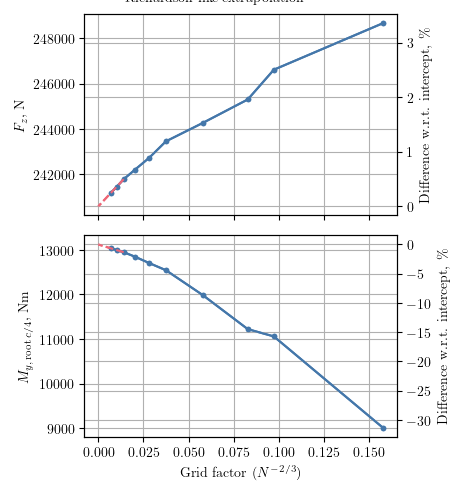

In [3]:
from scipy.stats import linregress


def read_monitor_point(f06_path, monitor_point_name):
    # Open the file and read all lines into a list for easy access by index
    with open(f06_path, "r") as file:
        lines = file.readlines()

    # Initialize control variables
    start_table = False  # flag to indicate the start of the desired table
    data_dict = {}  # dictionary to store parsed table data

    # Step 1: Locate the monitor point section by searching for the specified monitor point name
    for i, line in enumerate(lines):
        if f"MONITOR POINT NAME = {monitor_point_name}" in line:
            # Once the monitor point is found, start searching for the table header
            for j in range(i, len(lines)):
                # Look for the table header line, which marks the start of the data table
                if "AXIS      RIGID AIR       ELASTIC REST." in lines[j]:
                    start_table = True
                    table_start = j + 2  # Set table start two lines below the header
                    break
        # Exit the outer loop if the table start has been found
        if start_table:
            break

    # If the monitor point or table is not found, raise an error
    if not start_table:
        raise ValueError(f"Monitor point {monitor_point_name} not found in the file.")

    # Step 2: Read the table data line by line, starting from the identified table start line
    for k in range(table_start, len(lines)):
        # Check for an empty line or "PAGE" to mark the end of the table section
        if lines[k].strip() == "" or "PAGE" in lines[k]:
            break
        else:
            # Split the line into parts: first part is the axis label, rest are numerical values
            line_data = lines[k].split()
            axis = line_data[0]  # extract axis label (first item in line)
            # Convert remaining items to floats and store in a numpy array
            data = np.array([float(val) for val in line_data[1:]])
            # Store the axis and data array in the dictionary
            data_dict[axis] = data

    # Return the dictionary with axis labels as keys and data arrays as values
    return data_dict


# Define name of monitor point
monpnt1_name = "C/4"

# Define target lattice lengths and initialize arrays to store results
lattice_lengths = np.geomspace(CHORD / 2, CHORD / 20, 10)  # [m]
grid_factors = np.empty_like(lattice_lengths)
normal_force_array = np.empty_like(lattice_lengths)
moment_array = np.empty_like(lattice_lengths)

# Iterate over target lattice lengths
for i, target_length in enumerate(lattice_lengths):

    # Find number of chordwise and spanwise elements and store grid factor
    nchord = round(CHORD / target_length)
    nspan = round(L / target_length)
    no_elements = nchord * nspan
    grid_factors[i] = no_elements ** (-2 / 3)

    # Read monitor point data and store normal force and moment
    input_name = f"sol_144_{no_elements}_aero_elements"
    aerodynamic_loads = read_monitor_point(
        os.path.join(DATA_DIRECTORY_PATH, input_name + ".f06"), monpnt1_name
    )
    normal_force_array[i] = aerodynamic_loads["CZ"][0]
    moment_array[i] = aerodynamic_loads["CMY"][0]

# Create figure with two subplots
fig, axes = plt.subplots(
    2, 1, sharex=True, figsize=(TEXTWIDTH_INCHES * 0.75, TEXTWIDTH_INCHES * 0.8)
)

# Plot normal force vs grid factor
axes[0].computed_zorder = False
axes[0].plot(grid_factors, normal_force_array, "o-")
axes[0].set_ylabel("$F_z$, N")
axes[0].grid(True)

# Plot moment about c/4 vs grid factor
axes[1].computed_zorder = False
axes[1].plot(grid_factors, moment_array, "o-")
axes[1].set_ylabel("$M_{y,\,\mathrm{root}\,c/4}$, Nm")
axes[1].grid(True)
axes[1].set_xlabel("Grid factor ($N^{-2/3}$)")

# Extract the last three points of both plots to calculate the Richardson extrapolation
last_three_gf = grid_factors[-3:]
last_three_normal_forces = normal_force_array[-3:]
last_three_moments = moment_array[-3:]

# Perform linear regression for normal force and moment and calculate intercepts of Richardson extrapolation lines
_, intercept_normal_force, _, _, _ = linregress(last_three_gf, last_three_normal_forces)
_, intercept_moment, _, _, _ = linregress(last_three_gf, last_three_moments)

# Plot Richardson extrapolation lines
extrapolation_line = axes[0].plot(
    [grid_factors[-3], 0],
    [last_three_normal_forces[0], intercept_normal_force],
    "--",
    label="Richardson-like extrapolation",
)
axes[1].plot([grid_factors[-3], 0], [last_three_moments[0], intercept_moment], "--")

# Define function to calculate percentage difference
twin_scale = lambda y, y0: (y / y0 - 1) * 100

# Create list of forces and moments and list of intercepts
forces_moments_list = [normal_force_array, moment_array]
intercepts_list = [intercept_normal_force, intercept_moment]

# Loop over subplots to add twin axes
for i, intercept in enumerate(intercepts_list):
    # Create twin axes
    twin_ax = axes[i].twinx()

    # Plot percentage difference
    twin_ax.plot(grid_factors, twin_scale(forces_moments_list[i], intercept), "o-")

    # Set labels and grid for twin axes
    twin_ax.set_ylabel("Difference w.r.t. intercept, \%")
    twin_ax.grid(True)

    # Plot Richardson extrapolation lines on twin axes
    twin_ax.plot(
        [grid_factors[-3], 0],
        twin_scale(np.array([forces_moments_list[i][-3], intercept]), intercept),
        "--",
    )

# Invert y-axis of moments twin axes
twin_ax.invert_yaxis()
ymin, ymax = axes[i].get_ylim()  # get y-axis limits of main axes
twin_ax.set_ylim(
    twin_scale(ymin, intercept), twin_scale(ymax, intercept)
)  # set y-axis limits of twin axes to match percentage differences

# Add legend after tight layout
fig.tight_layout()
fig.legend(handles=extrapolation_line, bbox_to_anchor=(0.68, 1.04), frameon=False)

# Show and save plot
plt.show()
fig.savefig(
    os.path.join(FIGURES_DIRECTORY_PATH, "AeroMeshConvergence.pdf"),
    bbox_inches="tight",
    pad_inches=0,
)

## Comparison of the Initial Structures

Compare total normal force $F_z$ and buckling load factor $BLF$ obtained with the two aeroelastic coupling approaches.

In [4]:
from pyNastran.op2.op2 import read_op2

# Iterate over aeroelastic coupling approaches
coupling_approaches = ["hns", "lra"]
sol_105_op2_dict = {}
for approach in coupling_approaches:

    # Read op2 file
    op2_path = os.path.join(
        DATA_DIRECTORY_PATH, f"sol_105_sol_144_{approach}_initial.op2"
    )
    sol_105_op2_dict[approach] = read_op2(op2_path, load_geometry=True, debug=None)

    # Find and print total normal force and buckling load factor
    total_normal_force = np.sum(
        sol_105_op2_dict[approach].load_vectors[FIRST_SUBCASE_ID].data[:, :, Z_INDEX]
    )
    buckling_load_factor = (
        sol_105_op2_dict[approach].eigenvectors[SECOND_SUBCASE_ID].eigrs[0]
    )
    print(
        f"""
          Coupling method: {approach}
          Total normal force: {total_normal_force:.0f} N
          Buckling load factor: {buckling_load_factor:.2f}
          """
    )


          Coupling method: hns
          Total normal force: 244892 N
          Buckling load factor: 1.02
          

          Coupling method: lra
          Total normal force: 245773 N
          Buckling load factor: 1.01
          


Compare vertical displacement and twist angle along the span.

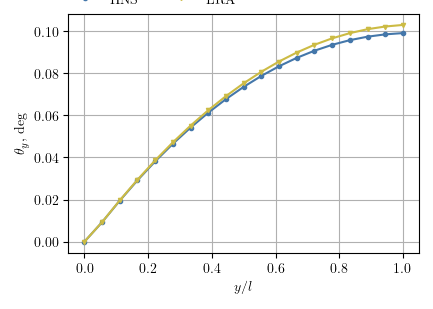

In [5]:
from resources import pynastran_utils


# Define function to calculate twist based on the vertical displacement of front and rear node of each rib
def calculate_twist(front_node_coord, front_node_disp, rear_node_coord, rear_node_disp):
    delta_theta = np.arctan(
        (
            (front_node_coord[Z_INDEX] + front_node_disp[Z_INDEX])
            - (rear_node_coord[Z_INDEX] + rear_node_disp[Z_INDEX])
        )
        / (
            (rear_node_coord[X_INDEX] + rear_node_disp[X_INDEX])
            - (front_node_coord[X_INDEX] + front_node_disp[X_INDEX])
        )
    ) - np.arctan(
        (front_node_coord[Z_INDEX] - rear_node_coord[Z_INDEX])
        / (rear_node_coord[X_INDEX] - front_node_coord[X_INDEX])
    )
    return delta_theta


# Find coordinates of all nodes
nodes_xyz = np.vstack([grid.xyz for grid in sol_105_op2_dict["hns"].nodes.values()])

# Initialize arrays to store node coordinates and ids
front_nodes_xyz = np.zeros((len(ribs_y_locations), 3))
front_nodes_ids = np.zeros_like(ribs_y_locations, dtype=int)
rear_nodes_ids = np.zeros_like(ribs_y_locations, dtype=int)
rear_nodes_xyz = np.zeros((len(ribs_y_locations), 3))

# Iterate over ribs
for j, rib_y in enumerate(ribs_y_locations):

    # Find front node id
    front_nodes_xyz[j] = np.array([0, rib_y, H / 2])
    front_nodes_ids[j] = (
        np.argmin(np.linalg.norm(nodes_xyz - front_nodes_xyz[j], axis=1)) + 1
    )

    # Find rear node id
    rear_nodes_xyz[j] = np.array([W, rib_y, H / 2])
    rear_nodes_ids[j] = (
        np.argmin(np.linalg.norm(nodes_xyz - rear_nodes_xyz[j], axis=1)) + 1
    )

# Create figure with one subplots
fig, ax = plt.subplots(figsize=(TEXTWIDTH_INCHES * 0.7, TEXTWIDTH_INCHES * 0.5))

# Iterate over aeroelastic coupling approaches
for i, approach in enumerate(coupling_approaches):

    # Read displacement data from OP2 object
    displacements = pynastran_utils.read_displacement_from_op2(
        op2=sol_105_op2_dict[approach],
        node_ids=np.hstack([front_nodes_ids, rear_nodes_ids]),
    )

    # Initialize array to store twist angles
    twist_angles = np.zeros_like(ribs_y_locations)

    # Iterate over ribs
    for j, rib_y in enumerate(ribs_y_locations):

        # Calculate twist angle from displacements of front and rear nodes
        twist_angles[j] = calculate_twist(
            front_nodes_xyz[j],
            displacements[front_nodes_ids[j]][FIRST_SUBCASE_ID],
            rear_nodes_xyz[j],
            displacements[rear_nodes_ids[j]][FIRST_SUBCASE_ID],
        )

    # Plot twist angles
    ax.plot(
        ribs_y_locations / L,
        np.degrees(twist_angles),
        label=approach.upper(),
        color=COLORS[i],
        marker=MARKERS[i],
    )

# Set labels and grid
ax.set_ylabel(r"$\theta_y$, deg")
ax.grid(True)
ax.set_xlabel("$y/l$")

# Add legend after tight layout
fig.tight_layout()
fig.legend(ncol=2, bbox_to_anchor=(0.57, 1.06), frameon=False)

# Show and save plot
plt.show()
fig.savefig(
    os.path.join(FIGURES_DIRECTORY_PATH, "InitialStructureTwistComparison.pdf"),
    bbox_inches="tight",
    pad_inches=0,
)

Plot buckling modes.

Critical buckling mode of model with hns coupling:


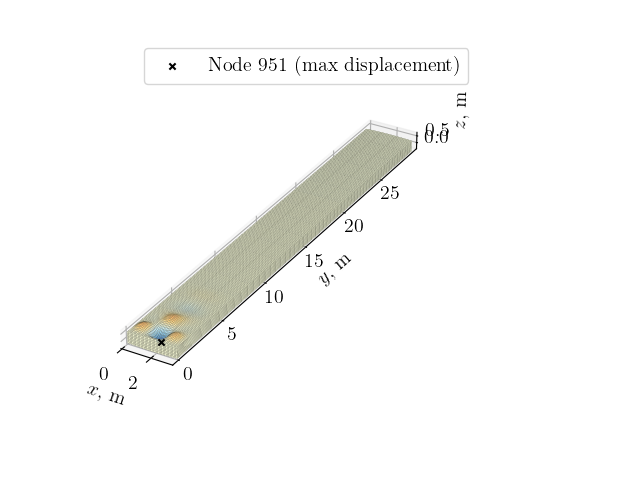

Critical buckling mode of model with lra coupling:


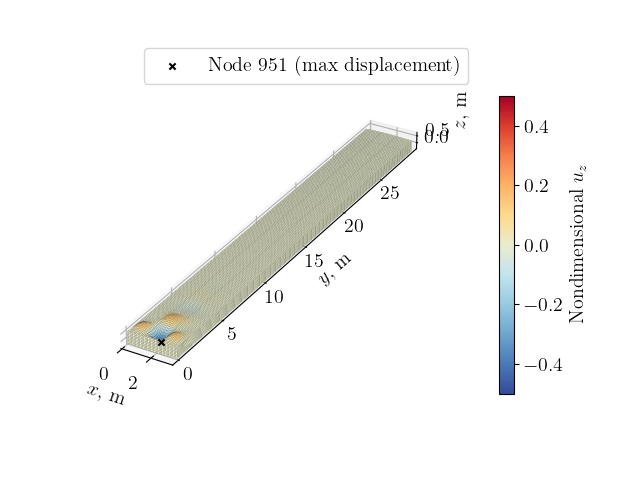

In [6]:
from resources import plot_utils


# Define function to adjust axes ticks and labels' position
def adjust_3d_plot(axes, colorbar=None):
    axes.locator_params(axis="x", nbins=3)  # set number of ticks of x-axis
    axes.locator_params(axis="z", nbins=2)  # set number of ticks of z-axis
    axes.tick_params(
        axis="y", which="major", pad=25
    )  # adjust position of ticks' label of y-axis
    axes.tick_params(
        axis="z", which="major", pad=6
    )  # adjust position of ticks' label of z-axis
    axes.yaxis.labelpad = 90  # adjust position of y-axis's label
    axes.zaxis.labelpad = 10  # adjust position of z-axis's label
    if colorbar is not None:
        colorbar.ax.set_position(
            colorbar.ax.get_position().shrunk(1.0, 0.62)
        )  # decrease colorbar size
        colorbar.ax.set_position(
            colorbar.ax.get_position().translated(-0.07, 0.18)
        )  # move colorbar upwards


# Define amplification factor of displacements
amplification_factor = 1.6

# Plot critical buckling mode of model with HNS coupling
key = "hns"
print(f"Critical buckling mode of model with {key} coupling:")
clim = [-0.5, 0.5]
plt.rcParams.update({"font.size": DEFAULT_FONT_SIZE * (1 / 0.7), "lines.markersize": 8})
fig, ax, cbar = plot_utils.plot_eigenvector(
    op2=sol_105_op2_dict[key],
    subcase_id=SECOND_SUBCASE_ID,
    displacement_component="tz",
    colormap="sunset",
    displacement_amplification_factor=amplification_factor,
    clim=clim,
)
cbar.remove()

# Plot maximum displacement node and add legend
root_node_id = plot_utils.plot_max_displacement_node(
    axes=ax,
    op2=sol_105_op2_dict[key],
    displacement_amplification_factor=amplification_factor,
)
ax.legend(bbox_to_anchor=(0.93, 0.92))

# Adjust plot and show it
adjust_3d_plot(ax, cbar)
plt.show()

# Save figure
BBOX_NO_COLORBAR = fig.bbox_inches.from_bounds(
    0.8, 0.5, 4.0, 3.9
)  # create bounding box for figure
label = key.title().replace(" ", "")  # label of figure
fig.savefig(
    os.path.join(FIGURES_DIRECTORY_PATH, f"InitialBucklingMode-{label}.png"),
    bbox_inches=BBOX_NO_COLORBAR,
    pad_inches=0,
)

# Plot critical buckling mode of model with curved skin
key = "lra"
print(f"Critical buckling mode of model with {key} coupling:")
fig, ax, cbar = plot_utils.plot_eigenvector(
    op2=sol_105_op2_dict[key],
    subcase_id=SECOND_SUBCASE_ID,
    displacement_component="tz",
    colormap="sunset",
    displacement_amplification_factor=amplification_factor,
    clim=clim,
)

# Plot maximum displacement node and add legend
plot_utils.plot_max_displacement_node(
    axes=ax,
    op2=sol_105_op2_dict[key],
    displacement_amplification_factor=amplification_factor,
)
ax.legend(bbox_to_anchor=(0.93, 0.92))

# Adjust plot and show it
adjust_3d_plot(ax, cbar)
plt.show()

# Save figure
BBOX_COLORBAR = fig.bbox_inches.from_bounds(
    0.8, 0.5, 5.2, 3.9
)  # create bounding box for figure
label = key.title().replace(" ", "")  # label of figure
fig.savefig(
    os.path.join(FIGURES_DIRECTORY_PATH, f"InitialBucklingMode-{label}.png"),
    bbox_inches=BBOX_COLORBAR,
    pad_inches=0,
)

# Reset default sizes
plt.rcParams.update(
    {"font.size": DEFAULT_FONT_SIZE, "lines.markersize": DEFAULT_MARKER_SIZE}
)

Compare nonlinear response.

C:\Users\qa21944\AppData\Local\Temp\ipykernel_24588\4201300602.py:184: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


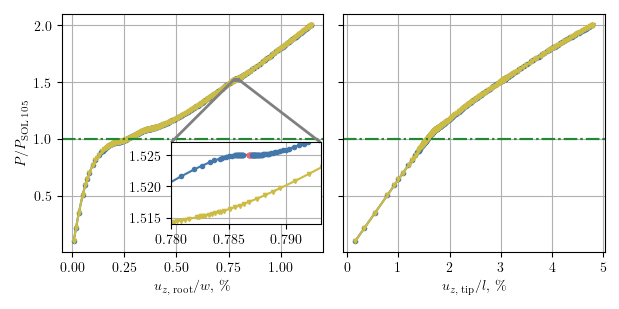

In [7]:
from resources import pynastran_utils
from mpl_toolkits.axes_grid1.inset_locator import mark_inset, zoomed_inset_axes


def plot_load_displacement_diagram(
    sol_106_op2_dict, input_name_dict, plot_node_ids, reference_lengths, max_nondimensional_load=2
):
    # Create one figure with two subplots side by side
    fig, axes = plt.subplots(
        1,
        len(plot_node_ids),
        sharey=True,
        figsize=(TEXTWIDTH_INCHES, TEXTWIDTH_INCHES * 0.5),
    )
    stable_lines = []

    # Read eigenvalues, load and displacement histories and plot load-displacement diagrams
    eigenvalues_dict = {}
    nondimensional_loads_dict = {}
    nondimensional_displacements_dict = {}
    for i, (key, input_name) in enumerate(input_name_dict.items()):
        # Read eigenvalues
        # Try to read eigenvalues from op2 file
        try:
            eigenvalues_dict[key] = (
                pynastran_utils.read_kllrh_lowest_eigenvalues_from_op2(
                    sol_106_op2_dict[key]
                )
            )
        # If not found, read from f06 file
        except:
            f06_path = os.path.join(DATA_DIRECTORY_PATH, input_name + ".f06")
            eigenvalues_dict[key] = (
                pynastran_utils.read_kllrh_lowest_eigenvalues_from_f06(f06_path)
            )

        # Read load and displacement histories from OP2 file
        load_factors, _, displacements = (
            pynastran_utils.read_load_displacement_history_from_op2(
                op2=sol_106_op2_dict[key], node_ids=plot_node_ids
            )
        )

        # Calculate nondimensional loads and displacements
        first_subcase_key = next(iter(load_factors))  # get the key of the first subcase
        nondimensional_loads_dict[key] = (
            load_factors[first_subcase_key] * max_nondimensional_load
        )
        nondimensional_displacements_dict[key] = {
            node_id: displacements[node_id][first_subcase_key][:, Z_INDEX] / ref_length
            for (node_id, ref_length) in zip(plot_node_ids, reference_lengths)
        }

        # Iterate over subplots and plot load-displacement diagrams
        for j, ax in enumerate(axes):
            plot_utils.plot_2d_load_displacements_stability(
                ax,
                nondimensional_displacements_dict[key][plot_node_ids[j]] * 100,
                nondimensional_loads_dict[key],
                eigenvalues_dict[key],
                MARKERS[i],
                COLORS[i],
            )

        # Add proxy artist for legend
        stable_lines.append(
            Line2D(
                [0],
                [0],
                linestyle="-",
                marker=MARKERS[i],
                color=COLORS[i],
                label=key.upper(),
            )
        )

    # Return
    return (
        fig,
        axes,
        nondimensional_displacements_dict,
        nondimensional_loads_dict,
        eigenvalues_dict,
        stable_lines,
    )


# Find id of tip node
tip_node_xyz = np.array([W / 2, L, 0])  # tip node is taken at the center of the tip rib
tip_node_id = (
    np.argmin(
        np.linalg.norm(
            np.array(
                [
                    sol_105_op2_dict["hns"].nodes[i].xyz
                    for i in sol_105_op2_dict["hns"].nodes
                ]
            )
            - tip_node_xyz,
            axis=1,
        )
    )
    + 1
)

# Create list of node ids to plot and corresponding reference lengths
plot_node_ids = [root_node_id, tip_node_id]
reference_lengths = [W, L]

# Initialize dictionary with names of input files
input_name_dict = {"hns": "sol_106_hns_initial_epsu5e-6", "lra": "sol_106_lra_initial"}

# Read op2 files
sol_106_op2_dict = {}
for i, (key, input_name) in enumerate(input_name_dict.items()):
    op2_path = os.path.join(DATA_DIRECTORY_PATH, input_name + ".op2")
    sol_106_op2_dict[key] = read_op2(
        op2_filename=op2_path,
        load_geometry=True,
        debug=None,
    )

# Plot load-displacement diagrams
(
    fig,
    axes,
    nondimensional_displacements_dict,
    nondimensional_loads_dict,
    eigenvalues_dict,
    stable_lines,
) = plot_load_displacement_diagram(sol_106_op2_dict, input_name_dict, plot_node_ids, reference_lengths)

# Plot linear buckling load lines
for count, key in enumerate(input_name_dict):
    for ax in axes:
        ax.axhline(
            y=1.0,
            color=GLASS_CEILING_COLOR,
            linestyle="-.",
            label=f"Linear buckling load",
        )

# Create proxy artists for unstable segments
unstable_line = Line2D([0], [0], linestyle="--", color=UNSTABLE_COLOR, label="Unstable")
linear_buckling_line = Line2D(
    [0], [0], linestyle="-.", color=GLASS_CEILING_COLOR, label="Linear buckling load"
)

# Set plot appearance for the first subplot
axes[0].set_xlabel("$u_{z,\,\mathrm{root}}/w$, \%")
axes[0].set_ylabel("$P/P_\mathrm{SOL\,105}$")
axes[0].grid(visible=True)

# Set plot appearance for the second subplot
axes[1].set_xlabel("$u_{z,\,\mathrm{tip}}/l$, \%")
axes[1].grid(visible=True)

# Create zoomed inset in root displacement plot
x1, x2 = 0.78, 0.793  # x-interval of interest for the first zoomed inset
y1, y2 = 1.514, 1.527  # y-interval of interest for the first zoomed inset
axins = zoomed_inset_axes(
    axes[0], zoom=55.0, bbox_to_anchor=(-0.06, 0.49), bbox_transform=ax.transAxes
)

# Iterate over coupling approaches
for i, key in enumerate(input_name_dict):
    # Plot applied load vs root displacement
    plot_utils.plot_2d_load_displacements_stability(
        axins,
        nondimensional_displacements_dict[key][plot_node_ids[0]] * 100,
        nondimensional_loads_dict[key],
        eigenvalues_dict[key],
        MARKERS[i],
        COLORS[i],
    )

# Set zoomed inset appearance
axins.set_xlim(x1, x2)  # Adjust the limits as needed
axins.set_ylim(y1, y2)  # Adjust the limits as needed
axins.grid(True)
mark_inset(axes[0], axins, loc1=1, loc2=2, fc="none", ec="0.5", linewidth=2, zorder=2)

# Add legend after tight layout
plt.tight_layout()
axes[0].legend(
    handles=stable_lines + [unstable_line, linear_buckling_line],
    loc="upper left",
    ncols=2,
    bbox_to_anchor=(-0.03, 1.25),
    frameon=False,
)

# Show and save plot
plt.show()
fig.savefig(
    os.path.join(FIGURES_DIRECTORY_PATH, "AeroLoadsInitialLoadDisplacementDiagram.pdf"),
    bbox_inches="tight",
    pad_inches=0,
)

Print nondimensional limit point load.

In [8]:
key = "hns"
first_negative_eigenvalue_index = np.where(eigenvalues_dict[key][0] < 0)[0][
    0
]  # find index of first negative eigenvalue
limit_point_load = np.mean(
    nondimensional_loads_dict[key][
        first_negative_eigenvalue_index - 1 : first_negative_eigenvalue_index + 1
    ]
)
print(f"Limit point load factor for model with HNS coupling: {limit_point_load:.2f}")

Limit point load factor for model with HNS coupling: 1.52


Compare deformation before and after snap-through for HNS approach.

Deformation before snap:


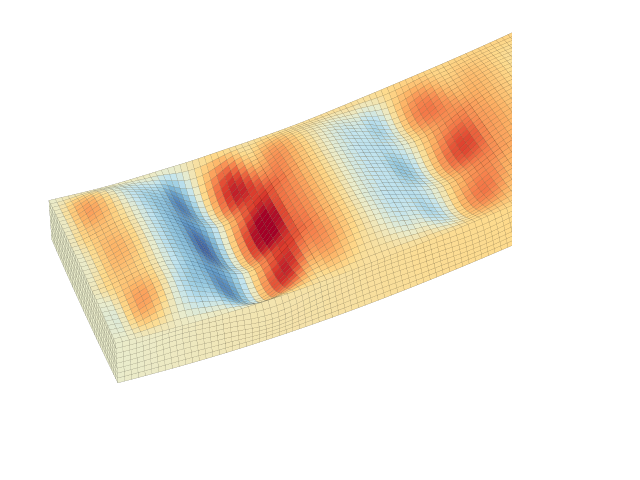

Deformation after snap


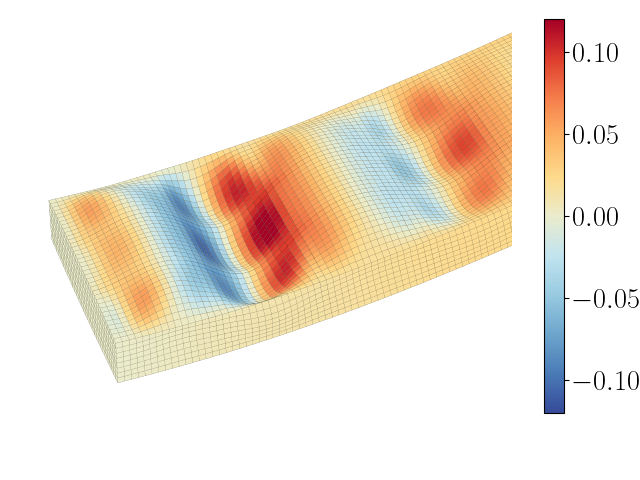

In [9]:
# Increase font size because figures are rendered side by side in the paper
plt.rcParams.update({"font.size": DEFAULT_FONT_SIZE * (1 / 0.49)})


# Define function to zoom deformation plot to root
def zoom_to_root(axes):
    axes.set_xlim(0, W)
    axes.set_ylim(0, 8 * H)
    axes.set_zlim(-H / 2, H)
    axes.set_box_aspect(
        [ub - lb for lb, ub in (getattr(axes, f"get_{a}lim")() for a in "xyz")]
    )
    plt.axis("off")
    axes.view_init(40, -20)


# Plot deformation just before limit point
print("Deformation before snap:")
amplification_factor = 10  # amplification factor for displacements
clim = [-0.12, 0.12]  # color limits for deformation plot
fig, ax, cbar = plot_utils.plot_deformation(
    op2=sol_106_op2_dict[key],
    subcase_id=FIRST_SUBCASE_ID,
    load_step=first_negative_eigenvalue_index,
    displacement_component="rx",
    colormap="sunset",
    displacement_amplification_factor=amplification_factor,
    clim=clim,
)  # plot buckling mode converting from mm to m
adjust_3d_plot(ax)
cbar.remove()
zoom_to_root(ax)
plt.show()
fig.savefig(
    os.path.join(FIGURES_DIRECTORY_PATH, "AeroLoadBeforeSnap.png"),
    bbox_inches="tight",
    pad_inches=0,
)

# Plot deformation just after snap
skip = 5  # number of increments to skip for selection of applied load after snap
subsequent_values = nondimensional_loads_dict[key][
    first_negative_eigenvalue_index + skip :
]  # consider only applied loads after snap
closest_index_in_subsequent = np.argmin(
    np.abs(limit_point_load - subsequent_values)
)  # find index of closest value to applied load at first limit point
closest_index = (
    first_negative_eigenvalue_index + skip + closest_index_in_subsequent
)  # sum found index to index of first negative eigenvalue
print("Deformation after snap")
fig, ax, cbar = plot_utils.plot_deformation(
    op2=sol_106_op2_dict[key],
    subcase_id=FIRST_SUBCASE_ID,
    load_step=closest_index + 1,
    displacement_component="rx",
    colormap="sunset",
    displacement_amplification_factor=amplification_factor,
    clim=clim,
)  # plot buckling mode converting from mm to m
adjust_3d_plot(ax)
cbar.ax.set_position(cbar.ax.get_position().shrunk(1.0, 0.82))  # decrease colorbar size
cbar.ax.set_position(
    cbar.ax.get_position().translated(0, 0.14)
)  # move colorbar upwards
zoom_to_root(ax)

# Show and save plot
plt.show()
fig.savefig(
    os.path.join(FIGURES_DIRECTORY_PATH, "AeroLoadAfterSnap.png"),
    bbox_inches="tight",
    pad_inches=0,
)

# Restore default sizes
plt.rcParams.update(
    {"font.size": DEFAULT_FONT_SIZE, "lines.markersize": DEFAULT_MARKER_SIZE}
)

## Comparison of the Linearly Optimized Structures

Plot history of linear buckling optimization with HNS approach.

Requested variables at last iteration:
- interp.t_cp: [0.01612872 0.00174289]
- nastran_solver.ks_buckling: [0.00119758]
- nastran_solver.ks_stress: [-3.25078176e+08]
- nastran_solver.mass: [15357.38662552]
Mass reduction: -42.0%


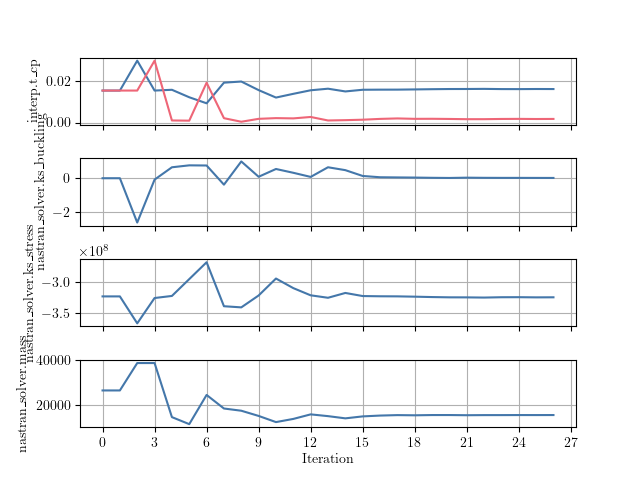

In [10]:
from resources import optimization_utils

# Plot optimization history
recorder_filename = "sol_144_hns_linear_opt.sql"
recorder_filepath = os.path.join(DATA_DIRECTORY_PATH, recorder_filename)
fig, axes, hns_linear_opt_histories = optimization_utils.plot_optimization_history(
    recorder_filepath
)

# Find index of last feasible design
hns_feasible_design_index = np.where(
    hns_linear_opt_histories["nastran_solver.ks_buckling"][:, 0] < OPTIMIZER_TOLERANCE
)[0][-1]

# Calculate and print mass reduction w.r.t. initial design
mass_reduction = 100 * (
    hns_linear_opt_histories["nastran_solver.mass"][hns_feasible_design_index, 0]
    / hns_linear_opt_histories["nastran_solver.mass"][0, 0]
    - 1
)
print(f"Mass reduction: {mass_reduction:.1f}%")

# Save plot
fig.savefig(
    os.path.join(FIGURES_DIRECTORY_PATH, "HnsLinearOptHistory.pdf"),
    bbox_inches="tight",
    pad_inches=0,
)

Plot history of linear buckling optimization with LRA approach.

Requested variables at last iteration:
- interp.t_cp: [0.01642411 0.00176202]
- nastran_solver.ks_buckling: [0.02131325]
- nastran_solver.ks_stress: [-3.23173376e+08]
- nastran_solver.mass: [15627.66085422]
Mass reduction: -40.9%


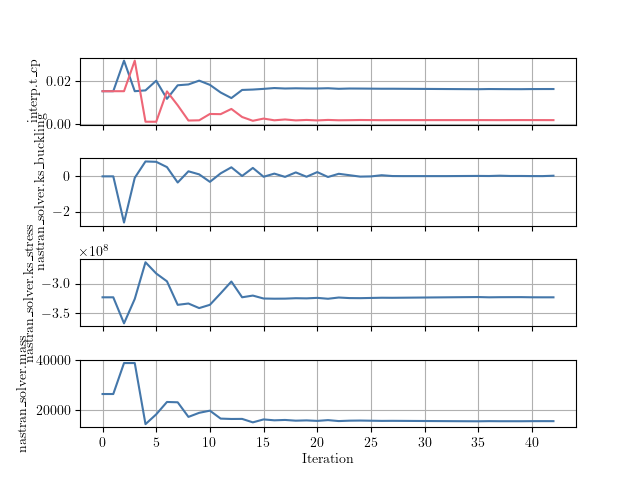

In [11]:
# Plot optimization history
recorder_filename = "sol_144_lra_linear_opt.sql"
recorder_filepath = os.path.join(DATA_DIRECTORY_PATH, recorder_filename)
fig, axes, lra_linear_opt_histories = optimization_utils.plot_optimization_history(
    recorder_filepath
)

# Find index of last feasible design
lra_feasible_design_index = np.where(
    lra_linear_opt_histories["nastran_solver.ks_buckling"][:, 0] < OPTIMIZER_TOLERANCE
)[0][-1]

# Calculate and print mass reduction w.r.t. initial design
mass_reduction = 100 * (
    lra_linear_opt_histories["nastran_solver.mass"][lra_feasible_design_index, 0]
    / lra_linear_opt_histories["nastran_solver.mass"][0, 0]
    - 1
)
print(f"Mass reduction: {mass_reduction:.1f}%")

# Save plot
fig.savefig(
    os.path.join(FIGURES_DIRECTORY_PATH, "LraLinearOptHistory.pdf"),
    bbox_inches="tight",
    pad_inches=0,
)

Plot bar chat of linearly optimized thickness distributions.

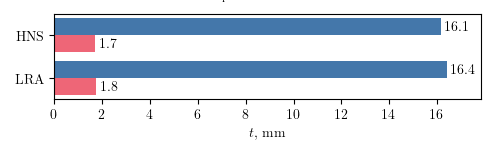

In [12]:
# Define function to plot bar chart of final thicknesses
def plot_thickness_bar_chart(
    hns_histories, lra_histories, figure_filename, iter_indices=[-1, -1]
):
    # Set up data for the bar chart converting from m to mm
    optimizations = ("HNS", "LRA")
    final_thicknesses = {
        "$t_\mathrm{root}$": (
            hns_histories["interp.t_cp"][iter_indices[0], 0] * 1e3,
            lra_histories["interp.t_cp"][iter_indices[1], 0] * 1e3,
        ),
        "$t_\mathrm{tip}$": (
            hns_histories["interp.t_cp"][iter_indices[0], 1] * 1e3,
            lra_histories["interp.t_cp"][iter_indices[1], 1] * 1e3,
        ),
    }

    # Plot bar chart with final thicknesses
    y_pos = np.arange(len(optimizations))  # the label locations
    height = 0.4  # the height of the bars
    multiplier = 0.5  # multiplier to separate bars
    fig, ax = plt.subplots(
        figsize=(TEXTWIDTH_INCHES * 0.8, TEXTWIDTH_INCHES * 0.25)
    )  # create figure and axis
    for (
        attribute,
        values,
    ) in final_thicknesses.items():  # iterate over attributes and values
        offset = height * multiplier  # offset to separate bars
        rects = ax.barh(
            y_pos + offset, values, height, label=attribute
        )  # plot bars converting from m to mm
        ax.bar_label(rects, padding=3, fmt="{:,.1f}")  # add labels to bars
        multiplier += 1.0  # increase multiplier to separate bars

    # Add some text for labels, title and custom x-axis tick labels, etc.
    ax.set_xlabel("$t$, mm")
    ax.invert_yaxis()  # labels read top-to-bottom
    ax.set_yticks(y_pos + height, optimizations)
    ax.set_xlim(
        right=max(max(v) for v in final_thicknesses.values()) + 1.4
    )  # set limits of x-axis

    # Save figure
    plt.tight_layout()  # ensures proper spacing between subplots
    ax.legend(
        bbox_to_anchor=(0.03, 1.01), ncols=2, frameon=False
    )  # add legend after tight layout
    plt.show()
    fig.savefig(
        os.path.join(FIGURES_DIRECTORY_PATH, figure_filename + ".pdf"),
        bbox_inches="tight",
        pad_inches=0,
    )


# Plot bar chart with final thicknesses
figure_name = "AeroLoadLinearOptThicknesses"
plot_thickness_bar_chart(
    hns_linear_opt_histories,
    lra_linear_opt_histories,
    figure_name,
    iter_indices=[hns_feasible_design_index, lra_feasible_design_index],
)

Plot bar chart of linearly optimized masses.

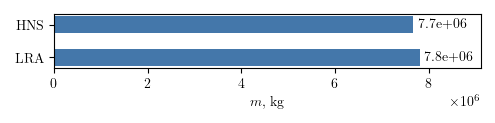

Mass difference between LRA and HNS models: 1.8%


In [13]:
# Define function to plot bar chart of final thicknesses
def plot_final_mass_bar_chart(
    hns_histories,
    lra_histories,
    figure_filename,
    iter_indices=[-1, -1],
    mass_scale_factor=1e3,
):

    # Find final masses of curved and flat skin model
    design_labels = ("HNS", "LRA")
    final_masses = np.array(
        [
            hns_histories["nastran_solver.mass"][iter_indices[0], 0],
            lra_histories["nastran_solver.mass"][iter_indices[1], 0],
        ]
    )

    # Make bar chart
    fig, ax = plt.subplots(figsize=(TEXTWIDTH_INCHES * 0.8, TEXTWIDTH_INCHES * 0.2))
    y_pos = np.arange(len(design_labels))  # position of bars
    p = ax.barh(y_pos, final_masses * mass_scale_factor, height=0.5)  # plot bars
    ax.bar_label(p, padding=3, fmt="{:,.1e}")  # add labels to bars
    ax.set_yticks(y_pos, labels=design_labels)  # set labels of y-axis
    ax.invert_yaxis()  # labels read top-to-bottom
    ax.set_xlabel("$m$, kg")  # set label of x-axis
    ax.set_xlim(right=np.max(final_masses) * mass_scale_factor + 1.3e6)  # set limits of x-axis

    # Save figure
    plt.tight_layout()  # ensures proper spacing between subplots
    plt.show()
    fig.savefig(
        os.path.join(FIGURES_DIRECTORY_PATH, figure_filename + ".pdf"),
        bbox_inches="tight",
        pad_inches=0,
    )
    
    # Print percentage difference between LRA and HNS models
    percentage_difference = (
        final_masses[1] / final_masses[0] - 1
    ) * 100  # calculate percentage difference
    print(
        f"Mass difference between LRA and HNS models: {percentage_difference:.1f}%"
    )


# Plot bar chart with final thicknesses
figure_name = "AeroLoadLinearOptMasses"
plot_final_mass_bar_chart(
    hns_linear_opt_histories,
    lra_linear_opt_histories,
    figure_name,
    iter_indices=[hns_feasible_design_index, lra_feasible_design_index],
    mass_scale_factor=1e3 / 2,
)  # account for the fact that BDF of SOL 144 returns mass of symmetric model

Compare total normal force of linearly optimized structures and twist angle along the span.


Coupling method: hns
Total normal force: 245431 N


Coupling method: lra
Total normal force: 253034 N



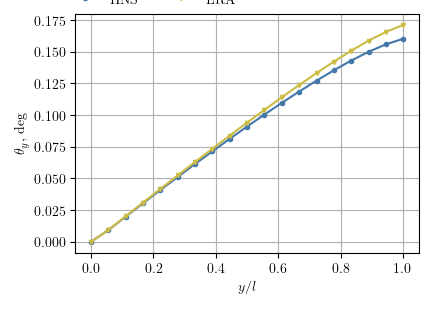

In [ ]:
# Initialize dictionary of OP2 objects
sol_105_op2_dict = {}

# Create figure with one subplots
fig, ax = plt.subplots(figsize=(TEXTWIDTH_INCHES * 0.7, TEXTWIDTH_INCHES * 0.5))


# Iterate over aeroelastic coupling approaches
for i, approach in enumerate(coupling_approaches):

    # Read op2 file
    op2_filepath = os.path.join(
        DATA_DIRECTORY_PATH, f"sol_105_sol_144_{approach}_linear_opt_feasible" + ".op2"
    )
    sol_105_op2_dict[approach] = read_op2(
        op2_filename=op2_filepath, load_geometry=True, debug=None
    )

    # Find and print total normal force
    total_normal_force = np.sum(
        sol_105_op2_dict[approach].load_vectors[FIRST_SUBCASE_ID].data[:, :, Z_INDEX]
    )
    print(
        f"""
Coupling method: {approach}
Total normal force: {total_normal_force:.0f} N\n"""
    )

    # Read displacement data from OP2 object
    displacements = pynastran_utils.read_displacement_from_op2(
        op2=sol_105_op2_dict[approach],
        node_ids=np.hstack([front_nodes_ids, rear_nodes_ids]),
    )

    # Initialize array to store twist angles
    twist_angles = np.zeros_like(ribs_y_locations)

    # Iterate over ribs
    for j, rib_y in enumerate(ribs_y_locations):

        # Calculate twist angle from displacements of front and rear nodes
        twist_angles[j] = calculate_twist(
            front_nodes_xyz[j],
            displacements[front_nodes_ids[j]][FIRST_SUBCASE_ID],
            rear_nodes_xyz[j],
            displacements[rear_nodes_ids[j]][FIRST_SUBCASE_ID],
        )

    # Plot twist angles
    ax.plot(
        ribs_y_locations / L,
        np.degrees(twist_angles),
        label=approach.upper(),
        color=COLORS[i],
        marker=MARKERS[i],
    )

# Set labels and grid
ax.set_ylabel(r"$\theta_y$, deg")
ax.grid(True)
ax.set_xlabel("$y/l$")

# Add legend after tight layout
fig.tight_layout()
fig.legend(ncol=2, bbox_to_anchor=(0.58, 1.06), frameon=False)

# Show and save plot
plt.show()
fig.savefig(
    os.path.join(FIGURES_DIRECTORY_PATH, "LinearOptTwistComparison.pdf"),
    bbox_inches="tight",
    pad_inches=0,
)

Compare critical buckling mode of linearly optimized structures.

Critical buckling mode of model with HNS:


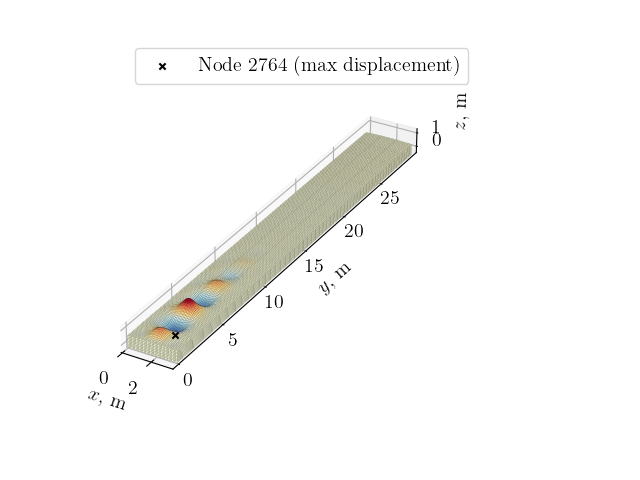

Critical buckling mode of model with LRA:


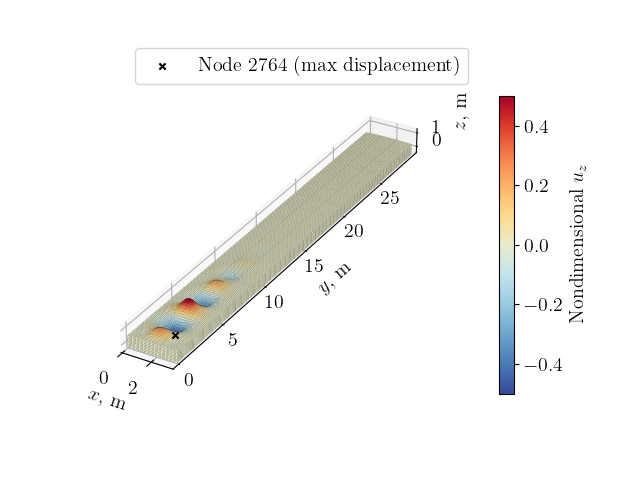

In [15]:
# Increase default font size for figures to be rendered side by side in the thesis
plt.rcParams.update({"font.size": DEFAULT_FONT_SIZE * (1 / 0.7)})

# Define amplification factor of displacements and color limits
amplification_factor = 1.5
clim = [-0.5, 0.5]

# Plot critical buckling mode of model with HNS
key = "hns"
print(f"Critical buckling mode of model with {key.upper()}:")
fig, ax, cbar = plot_utils.plot_eigenvector(
    op2=sol_105_op2_dict[key],
    subcase_id=SECOND_SUBCASE_ID,
    displacement_component="tz",
    colormap="sunset",
    displacement_amplification_factor=amplification_factor,
    clim=clim,
)

# Plot maximum displacement node and add legend
max_disp_node_id = plot_utils.plot_max_displacement_node(
    axes=ax,
    op2=sol_105_op2_dict[key],
    displacement_amplification_factor=amplification_factor,
)
ax.legend(bbox_to_anchor=(0.93, 0.92))

# Adjust plot and show it
cbar.remove()
adjust_3d_plot(ax, cbar)
plt.show()

# Save figure
label = key.title().replace(" ", "")  # label of figure
fig.savefig(
    os.path.join(FIGURES_DIRECTORY_PATH, f"LinearOptBucklingMode{label}.png"),
    bbox_inches=BBOX_NO_COLORBAR,
    pad_inches=0,
)

# Plot critical buckling mode of model with LRA
key = "lra"
print(f"Critical buckling mode of model with {key.upper()}:")
fig, ax, cbar = plot_utils.plot_eigenvector(
    op2=sol_105_op2_dict[key],
    subcase_id=SECOND_SUBCASE_ID,
    displacement_component="tz",
    colormap="sunset",
    displacement_amplification_factor=amplification_factor,
    clim=clim,
)

# Plot maximum displacement node and add legend
_ = plot_utils.plot_max_displacement_node(
    axes=ax,
    op2=sol_105_op2_dict[key],
    displacement_amplification_factor=amplification_factor,
)
ax.legend(bbox_to_anchor=(0.93, 0.92))

# Adjust plot and show it
adjust_3d_plot(ax, cbar)
plt.show()

# Save figure
label = key.title().replace(" ", "")  # label of figure
fig.savefig(
    os.path.join(FIGURES_DIRECTORY_PATH, f"LinearOptBucklingMode{label}.png"),
    bbox_inches=BBOX_COLORBAR,
    pad_inches=0,
)

# Reset default font size
plt.rcParams.update({"font.size": DEFAULT_FONT_SIZE})

Compare load-displacement diagrams of nonlinear analyses.

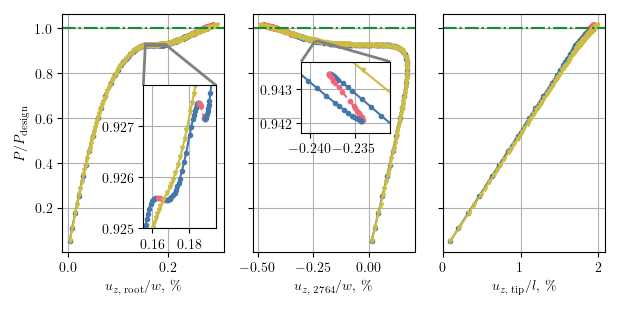

In [16]:
# Create list of node ids to plot and corresponding reference lengths
plot_node_ids = [root_node_id, max_disp_node_id, tip_node_id]
reference_lengths = [W, W, L]

# Initialize dictionary with names of input files
input_name_dict = {
    "hns": "sol_106_hns_linear_opt_eigenvectors",
    "lra": "sol_106_lra_linear_opt_eigenvectors",
}

# Read op2 files
for i, (key, input_name) in enumerate(input_name_dict.items()):
    op2_path = os.path.join(DATA_DIRECTORY_PATH, input_name + ".op2")
    sol_106_op2_dict[key] = read_op2(
        op2_filename=op2_path,
        load_geometry=True,
        debug=None,
    )

# Plot load-displacement diagrams
(
    fig,
    axes,
    nondimensional_displacements_dict,
    nondimensional_loads_dict,
    eigenvalues_dict,
    stable_lines,
) = plot_load_displacement_diagram(sol_106_op2_dict, input_name_dict, plot_node_ids, reference_lengths)

# Plot linear buckling load lines
for count, key in enumerate(input_name_dict):
    for ax in axes:
        ax.axhline(
            y=1.0,
            color=GLASS_CEILING_COLOR,
            linestyle="-.",
            label=f"Linear buckling load",
        )

# Create proxy artists for unstable segments
unstable_line = Line2D([0], [0], linestyle="--", color=UNSTABLE_COLOR, label="Unstable")
linear_buckling_line = Line2D(
    [0], [0], linestyle="-.", color=GLASS_CEILING_COLOR, label="Linear buckling load"
)

# Set plot appearance for the first subplot
axes[0].set_xlabel("$u_{z,\,\mathrm{root}}/w$, \%")
axes[0].set_ylabel("$P/P_\mathrm{design}$")
axes[0].grid(visible=True)

# Set plot appearance for the second subplot
axes[1].set_xlabel(f"$u_{{z,\,\mathrm{{{max_disp_node_id:d}}}}}/w$, \%")
axes[1].grid(visible=True)

# Set plot appearance for the third subplot
axes[2].set_xlabel("$u_{z,\,\mathrm{tip}}/l$, \%")
axes[2].grid(visible=True)

# Create zoomed inset in root displacement plot
x1, x2 = 0.155, 0.195  # x-interval of interest for the first zoomed inset
y1, y2 = 0.925, 0.9278  # y-interval of interest for the first zoomed inset
axin1 = axes[0].inset_axes([.5, .1, 0.45, 0.6], xlim=(x1, x2), ylim=(y1, y2))

# Iterate over coupling approaches
for i, key in enumerate(input_name_dict):
    # Plot applied load vs root displacement
    plot_utils.plot_2d_load_displacements_stability(
        axin1,
        nondimensional_displacements_dict[key][plot_node_ids[0]] * 100,
        nondimensional_loads_dict[key],
        eigenvalues_dict[key],
        MARKERS[i],
        COLORS[i],
    )

# Set zoomed inset appearance
# axin1.set_yticklabels([])
axin1.grid(True)
mark_inset(axes[0], axin1, loc1=1, loc2=2, fc="none", ec="0.5", linewidth=2, zorder=2)

# Create zoomed inset in central displacement plot
x1, x2 = -.241, -.231  # x-interval of interest for the first zoomed inset
y1, y2 = 0.9417, 0.9438  # y-interval of interest for the first zoomed inset
axin2 = axes[1].inset_axes([.3, .5, 0.55, 0.3], xlim=(x1, x2), ylim=(y1, y2))

# Iterate over coupling approaches
for i, key in enumerate(input_name_dict):
    # Plot applied load vs root displacement
    plot_utils.plot_2d_load_displacements_stability(
        axin2,
        nondimensional_displacements_dict[key][plot_node_ids[1]] * 100,
        nondimensional_loads_dict[key],
        eigenvalues_dict[key],
        MARKERS[i],
        COLORS[i],
    )

# Set zoomed inset appearance
axin2.grid(True)
mark_inset(axes[1], axin2, loc1=1, loc2=2, fc="none", ec="0.5", linewidth=2, zorder=2)

# Add legend after tight layout
plt.tight_layout()
axes[0].legend(
    handles=stable_lines + [unstable_line, linear_buckling_line],
    loc="upper left",
    ncols=2,
    bbox_to_anchor=(-0.03, 1.25),
    frameon=False,
)

# Show and save plot
plt.show()
fig.savefig(
    os.path.join(
        FIGURES_DIRECTORY_PATH, "AeroLoadsLinearOptLoadDisplacementDiagram.pdf"
    ),
    bbox_inches="tight",
    pad_inches=0,
)

Compare applied load at first limit point.

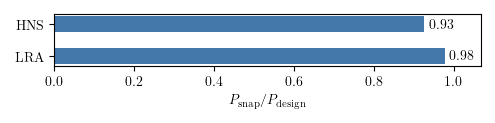


Percentage differences of limit point load of LRA w.r.t. HNS: 5.5%



In [17]:
def plot_limit_point_load_bar_chart(
    key_list, eigenvalues_dict, nondimensional_loads_dict, figure_name
):
    # Find limit point load for each analysis
    first_negative_eigenvalue_index_dict = {}
    limit_point_loads = []
    for key in key_list:
        first_negative_eigenvalue_index_dict[key] = np.where(
            eigenvalues_dict[key][0] < 0
        )[0][
            0
        ]  # find index of first negative eigenvalue
        limit_point_loads.append(
            np.mean(
                nondimensional_loads_dict[key][
                    first_negative_eigenvalue_index_dict[key]
                    - 1 : first_negative_eigenvalue_index_dict[key]
                    + 1
                ]
            )
        )  # calculate nondimensional applied load at limit point as the mean between the last stable and first unstable load

    # Plot bar chart with limit point loads
    fig, ax = plt.subplots(figsize=(TEXTWIDTH_INCHES * 0.8, TEXTWIDTH_INCHES * 0.2))
    y_pos = np.arange(len(input_name_dict.keys()))  # position of bars
    p = ax.barh(y_pos, limit_point_loads, height=0.5)  # plot bars
    ax.bar_label(p, padding=3, fmt="{:,.2f}")  # add labels to bars
    ax.set_yticks(y_pos, labels=(key.upper() for key in input_name_dict.keys()))  # set labels of y-axis
    ax.invert_yaxis()  # labels read top-to-bottom
    ax.set_xlabel("$P_\mathrm{snap}/P_\mathrm{design}$")  # set label of x-axis
    ax.set_xlim(right=np.max(limit_point_loads) + 0.09)  # set limits of x-axis

    # Save figure
    plt.tight_layout()  # Ensures proper spacing between subplots
    plt.show()
    fig.savefig(
        os.path.join(FIGURES_DIRECTORY_PATH, figure_name + ".pdf"),
        bbox_inches="tight",
        pad_inches=0,
    )

    # Return list of limit point loads and dictionary with indices of first negative eigenvalues
    return limit_point_loads, first_negative_eigenvalue_index_dict


# Plot bar chart with limit point loads
limit_point_loads, first_negative_eigenvalue_index_dict = (
    plot_limit_point_load_bar_chart(
        ["hns", "lra"],
        eigenvalues_dict,
        nondimensional_loads_dict,
        "AeroLoadsLimitPointLoadBarChart",
    )
)

# Calculate percentage differences w.r.t. distributed non-follower forces
percentage_difference = (
    100 * (limit_point_loads[1] - limit_point_loads[0]) / limit_point_loads[0]
)
print(
    f"""
Percentage differences of limit point load of LRA w.r.t. HNS: {percentage_difference:.1f}%
"""
)

Plot first 4 critical eigenvectors for model with HNS approach.

Eigenvector of instability 1, P/P_design=0.93:


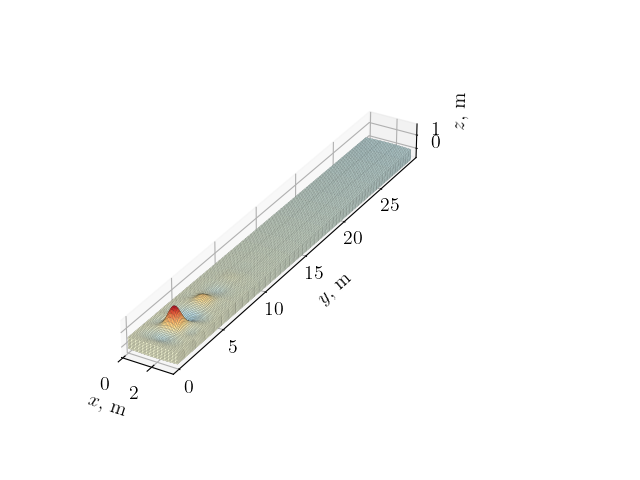

Eigenvector of instability 2, P/P_design=0.93:


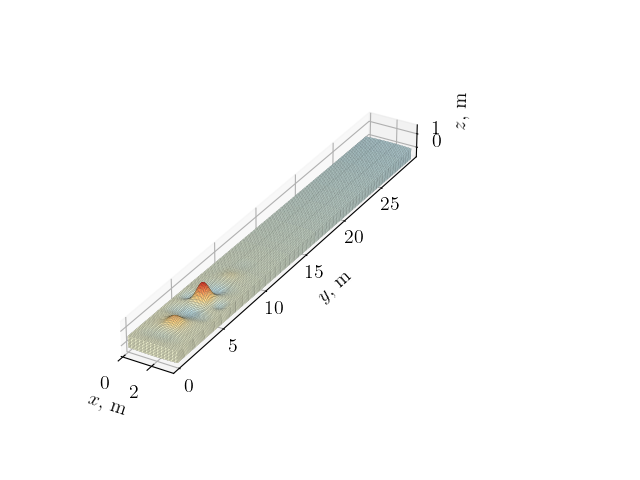

Eigenvector of instability 3, P/P_design=0.94:


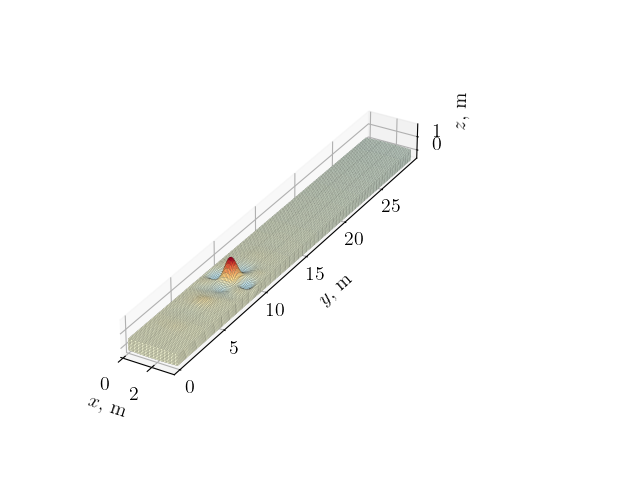

Eigenvector of instability 4, P/P_design=0.98:


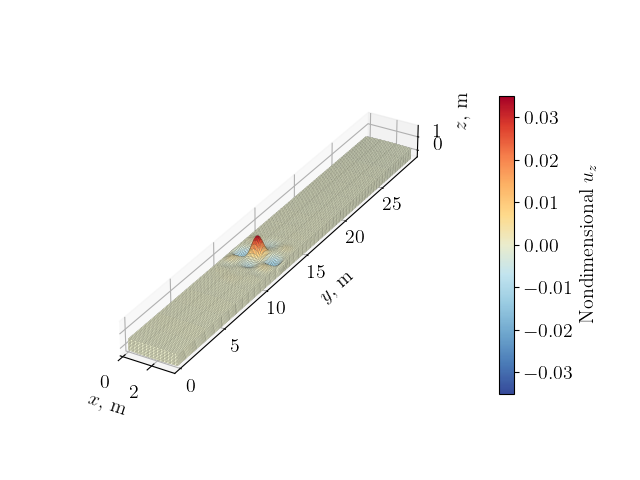

In [18]:
# Increase default font size for figures to be rendered side by side in the thesis
plt.rcParams.update({"font.size": DEFAULT_FONT_SIZE * (1 / 0.7)})

# Function to find indices where the number of negative eigenvalues increases between increments
def find_negative_eigenvalue_increases(eigenvalues, eigrs):
    """
    Find indices in eigrs where the number of negative eigenvalues
    increases between consecutive increments, accounting for nans in the
    eigenvalues array.
    
    Parameters
    ----------
    eigenvalues: ndarray
        2D array of shape (n_eigenvalues, n_increments) containing
        eigenvalues for each increment, may contain nans
    eigrs: list
        list containing all non-nan eigenvalues listed sequentially
    
    Returns
    -------
    (eigenvalues_increase_indices, eigrs_increase_indices): tuple
        indices where increases occur and number of negative eigenvalues
        at each increment
    """
    # Convert eigrs to numpy array
    eigrs_array = np.array(eigrs)
    
    # Get number of increments
    _, n_increments = eigenvalues.shape
    
    # Count valid (non-nan) eigenvalues per increment
    valid_counts = np.sum(~np.isnan(eigenvalues), axis=0)
    
    # Count negative eigenvalues per increment
    neg_counts = np.zeros(n_increments)
    current_idx = 0
    
    # Store the indices in eigrs where each increment starts
    increment_start_indices = np.zeros(n_increments, dtype=int)
    
    for i in range(n_increments):
        count = valid_counts[i]
        # Count negative eigenvalues in this increment
        neg_counts[i] = np.sum(
            eigrs_array[current_idx:current_idx + count] < 0)
        increment_start_indices[i] = current_idx
        current_idx += count
        
    # Find indices of columns where number of negative eigenvalues increases
    eigenvalues_increase_indices = np.where(np.diff(neg_counts) > 0)[0] + 1
    
    # Find where number of negative eigenvalues increases
    eigrs_increase_indices = increment_start_indices[
        eigenvalues_increase_indices]
    
    # Return the indices where increases occur and the number of negative eigenvalues at each increment
    return eigenvalues_increase_indices, eigrs_increase_indices

# Find the indices corresponding to the instabilities
key = "hns"
eigenvectors_key = next(iter(sol_106_op2_dict[key].eigenvectors))  # get the key of the subcase containing the eigenvectors
increment_instability_indices, plot_instability_indices =\
    find_negative_eigenvalue_increases(
        eigenvalues_dict[key], sol_106_op2_dict[key].eigenvectors[eigenvectors_key].eigrs)

# Plot the eigenvectors of the first three instabilities
amplification_factor = 40  # amplification factor for displacements
clim = [-.035, .035]  # color limits for deformation plot
for i in range(3):
    print(f"Eigenvector of instability {i + 1}, P/P_design={nondimensional_loads_dict[key][increment_instability_indices[i]]:.2f}:")
    fig, ax, cbar = plot_utils.plot_eigenvector(
        op2=sol_106_op2_dict[key],
        subcase_id=eigenvectors_key,
        eigenvector_number=plot_instability_indices[i] + 1,
        displacement_component="tz",
        colormap="sunset",
        displacement_amplification_factor=amplification_factor,
        clim=clim,
    )

    # Adjust plot and show it
    cbar.remove()
    adjust_3d_plot(ax, cbar)
    plt.show()

    # Save figure
    fig.savefig(
        os.path.join(FIGURES_DIRECTORY_PATH, f"LinearOptEigenvector{key.title()}{i+1:d}.png"),
        bbox_inches=BBOX_NO_COLORBAR,
        pad_inches=0,
    )

# Fourth instability
i = 3
print(f"Eigenvector of instability {i + 1}, P/P_design={nondimensional_loads_dict[key][increment_instability_indices[i]]:.2f}:")
fig, ax, cbar = plot_utils.plot_eigenvector(
    op2=sol_106_op2_dict[key],
    subcase_id=eigenvectors_key,
    eigenvector_number=plot_instability_indices[i] + 1,
    displacement_component="tz",
    colormap="sunset",
    displacement_amplification_factor=amplification_factor,
    clim=clim,
)

# Adjust plot and show it
adjust_3d_plot(ax, cbar)
plt.show()

# Save figure
fig.savefig(
    os.path.join(FIGURES_DIRECTORY_PATH, f"LinearOptEigenvector{key.title()}{i+1:d}.png"),
    bbox_inches=BBOX_COLORBAR,
    pad_inches=0,
)


# Reset default font size
plt.rcParams.update({"font.size": DEFAULT_FONT_SIZE})

Plot first 4 critical eigenvectors for model with LRA approach.

Eigenvector of instability 1, P/P_design=0.98:


c:\Users\qa21944\Github\phd-jupyter-notebooks\notebooks\resources\plot_utils.py:587: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig = plt.figure()


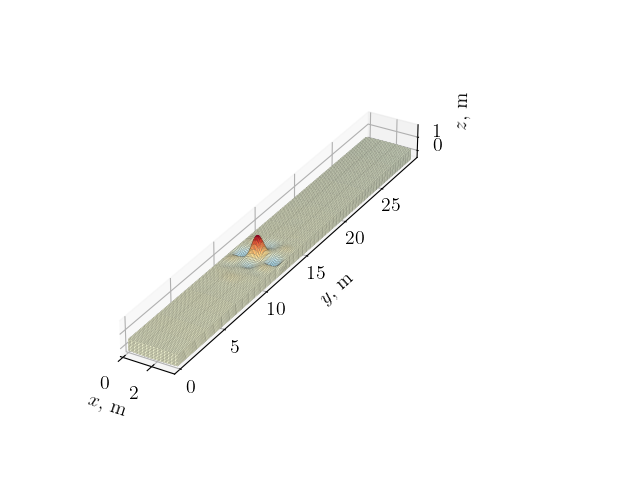

Eigenvector of instability 2, P/P_design=1.00:


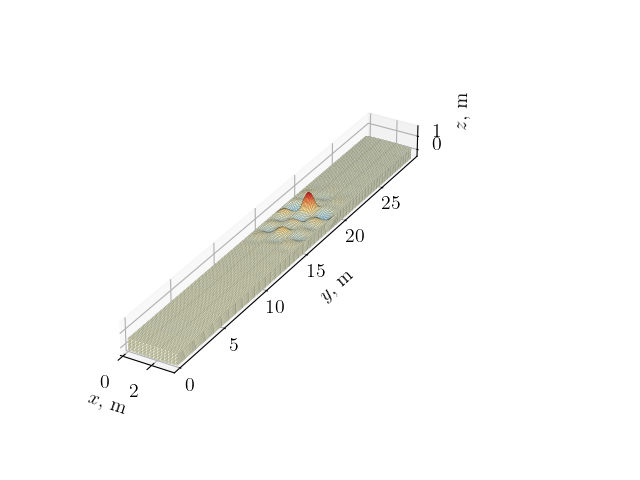

Eigenvector of instability 3, P/P_design=1.00:


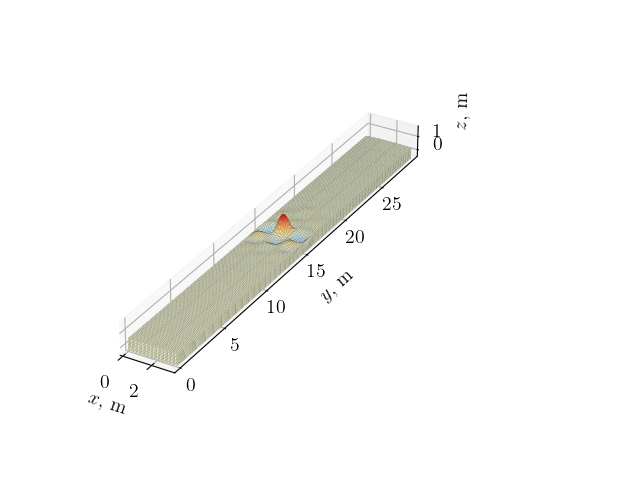

Eigenvector of instability 4, P/P_design=1.00:


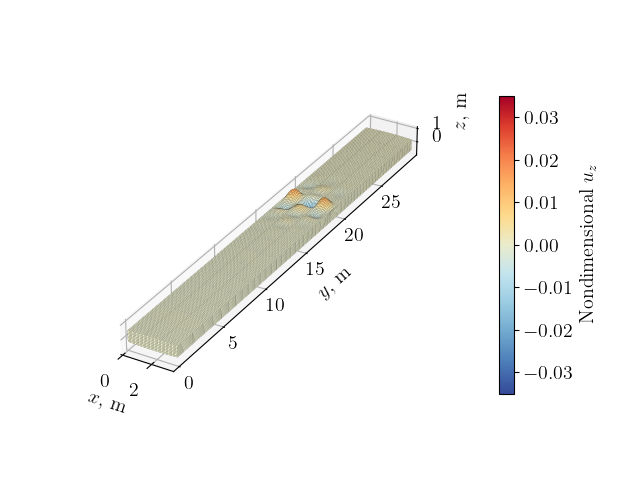

In [19]:
# Increase default font size for figures to be rendered side by side in the thesis
plt.rcParams.update({"font.size": DEFAULT_FONT_SIZE * (1 / 0.7)})

# Find the indices corresponding to the instabilities
key = "lra"
eigenvectors_key = next(iter(sol_106_op2_dict[key].eigenvectors))  # get the key of the subcase containing the eigenvectors
increment_instability_indices, plot_instability_indices =\
    find_negative_eigenvalue_increases(
        eigenvalues_dict[key], sol_106_op2_dict[key].eigenvectors[eigenvectors_key].eigrs)

# Plot the eigenvector at first three instability
for i in range(3):
    print(f"Eigenvector of instability {i + 1}, P/P_design={nondimensional_loads_dict[key][increment_instability_indices[i]]:.2f}:")
    fig, ax, cbar = plot_utils.plot_eigenvector(
        op2=sol_106_op2_dict[key],
        subcase_id=eigenvectors_key,
        eigenvector_number=plot_instability_indices[i] + 1,
        displacement_component="tz",
        colormap="sunset",
        displacement_amplification_factor=amplification_factor,
        clim=clim,
    )

    # Adjust plot and show it
    cbar.remove()
    adjust_3d_plot(ax, cbar)
    plt.show()

    # Save figure
    fig.savefig(
        os.path.join(FIGURES_DIRECTORY_PATH, f"LinearOptEigenvector{key.title()}{i+1:d}.png"),
        bbox_inches=BBOX_NO_COLORBAR,
        pad_inches=0,
    )

# Fourth instability (skip i=3 beacuse it is actually a second eigenvalue turning negative)
i = 4
print(f"Eigenvector of instability {i}, P/P_design={nondimensional_loads_dict[key][increment_instability_indices[i]]:.2f}:")
fig, ax, cbar = plot_utils.plot_eigenvector(
    op2=sol_106_op2_dict[key],
    subcase_id=eigenvectors_key,
    eigenvector_number=plot_instability_indices[i] + 1,
    displacement_component="tz",
    colormap="sunset",
    displacement_amplification_factor=amplification_factor,
    clim=clim,
)

# Adjust plot and show it
adjust_3d_plot(ax, cbar)
plt.show()

# Save figure
fig.savefig(
    os.path.join(FIGURES_DIRECTORY_PATH, f"LinearOptEigenvector{key.title()}{i:d}.png"),
    bbox_inches=BBOX_COLORBAR,
    pad_inches=0,
)


# Reset default font size
plt.rcParams.update({"font.size": DEFAULT_FONT_SIZE})

Plot deformation across snap of HNS model.

Deformation before snap (P/P_design=0.926):


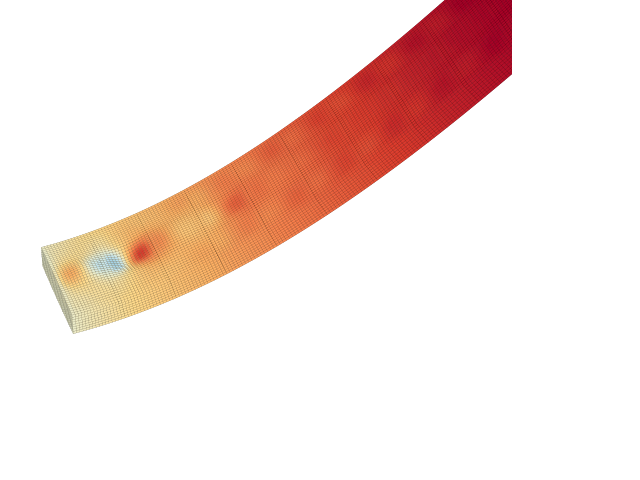

Deformation after snap (P/P_design=0.926):


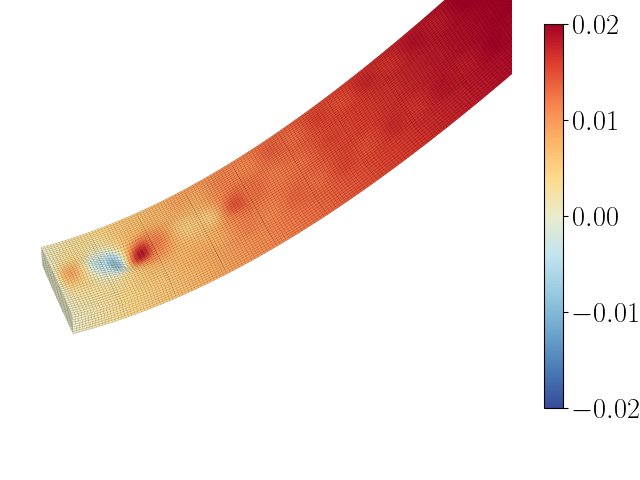

In [20]:
# Define function to zoom deformation plot to midspan
def zoom_to_midspan(axes):
    axes.set_xlim(0, W)
    axes.set_ylim(0, L / 2)
    axes.set_zlim(-H / 2, H)
    axes.set_box_aspect(
        [ub - lb for lb, ub in (getattr(axes, f"get_{a}lim")() for a in "xyz")]
    )
    plt.axis("off")
    axes.view_init(40, -20)


# Increase font size because figures are rendered side by side in the paper
plt.rcParams.update({"font.size": DEFAULT_FONT_SIZE * (1 / 0.49)})

# Plot deformation just before limit point
key = "hns"
limit_point_load = nondimensional_loads_dict[key][first_negative_eigenvalue_index_dict[key] - 1]
print(f"Deformation before snap (P/P_design={limit_point_load:.3f}):")
first_subcase_key = next(
    iter(sol_106_op2_dict[key].displacements)
)  # get the key of the first subcase
amplification_factor = 40  # amplification factor for displacements
clim = [-0.02, 0.02]  # color limits for deformation plot
fig, ax, cbar = plot_utils.plot_deformation(
    op2=sol_106_op2_dict[key],
    subcase_id=first_subcase_key,
    load_step=first_negative_eigenvalue_index_dict[key],
    displacement_component="rx",
    colormap="sunset",
    displacement_amplification_factor=amplification_factor,
    clim=clim,
)  # plot buckling mode converting from mm to m
adjust_3d_plot(ax)
cbar.remove()
zoom_to_midspan(ax)
plt.show()
fig.savefig(
    os.path.join(FIGURES_DIRECTORY_PATH, "LinearOptHnsBeforeSnap.png"),
    bbox_inches="tight",
    pad_inches=0,
)

# Calculate index at the end of snap (closest load to limit point load)
skip = 5  # number of increments to skip for selection of applied load after snap
subsequent_values = nondimensional_loads_dict[key][
    first_negative_eigenvalue_index_dict[key] + skip :
]  # consider only applied loads after snap
closest_index_in_subsequent = np.argmin(
    np.abs(limit_point_load - subsequent_values)
)  # find index of closest value to applied load at first limit point
closest_index = (
    first_negative_eigenvalue_index_dict[key] + skip + closest_index_in_subsequent
)  # sum found index to index of first negative eigenvalue

# Plot deformation just after snap
print(f"Deformation after snap (P/P_design={nondimensional_loads_dict[key][closest_index]:.3f}):")
fig, ax, cbar = plot_utils.plot_deformation(
    op2=sol_106_op2_dict[key],
    subcase_id=first_subcase_key,
    load_step=closest_index + 1,
    displacement_component="rx",
    colormap="sunset",
    displacement_amplification_factor=amplification_factor,
    clim=clim,
)  # plot buckling mode converting from mm to m
adjust_3d_plot(ax)
cbar.ax.set_position(cbar.ax.get_position().shrunk(1.0, 0.8))  # decrease colorbar size
cbar.ax.set_position(
    cbar.ax.get_position().translated(0, 0.15)
)  # move colorbar upwards
zoom_to_midspan(ax)

# Show and save plot
plt.show()
fig.savefig(
    os.path.join(FIGURES_DIRECTORY_PATH, "LinearOptHnsAfterSnap.png"),
    bbox_inches="tight",
    pad_inches=0,
)

# Restore default sizes
plt.rcParams.update(
    {"font.size": DEFAULT_FONT_SIZE, "lines.markersize": DEFAULT_MARKER_SIZE}
)

Plot deformation across snap of LRA model.

Deformation before snap (P/P_design=0.976):


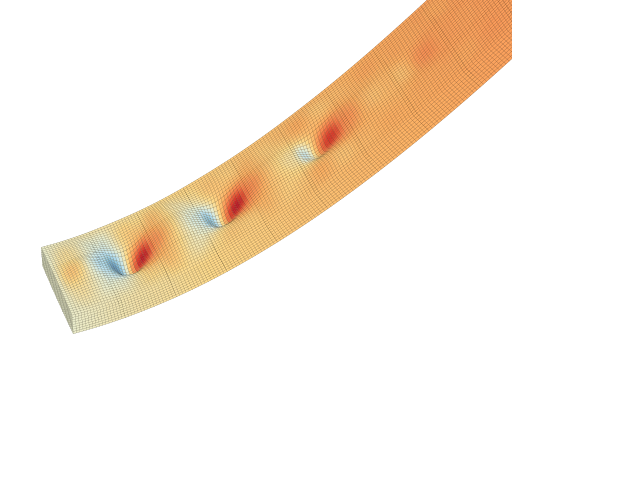

Deformation after snap (P/P_design=0.976):


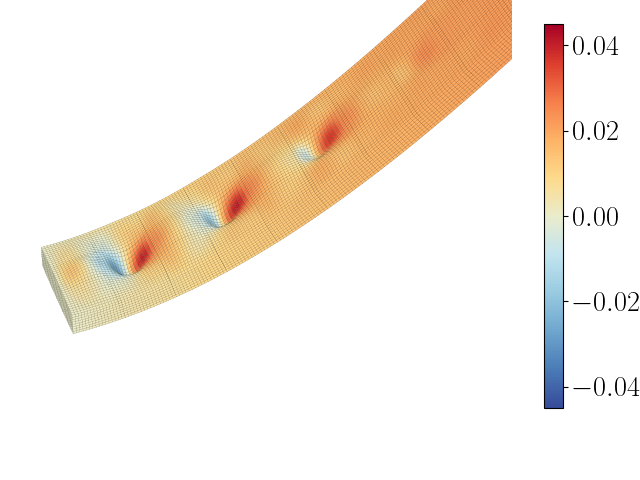

In [21]:
# Increase font size because figures are rendered side by side in the paper
plt.rcParams.update({"font.size": DEFAULT_FONT_SIZE * (1 / 0.49)})
key = "lra"

# Plot deformation just before limit point
limit_point_load = nondimensional_loads_dict[key][first_negative_eigenvalue_index_dict[key] - 1]
print(f"Deformation before snap (P/P_design={limit_point_load:.3f}):")
clim = [-.045, .045]
fig, ax, cbar = plot_utils.plot_deformation(
    op2=sol_106_op2_dict[key],
    subcase_id=first_subcase_key,
    load_step=first_negative_eigenvalue_index_dict[key],
    displacement_component="rx",
    colormap="sunset",
    displacement_amplification_factor=amplification_factor,
    clim=clim,
)  # plot buckling mode converting from mm to m
adjust_3d_plot(ax)
cbar.remove()
zoom_to_midspan(ax)
plt.show()
fig.savefig(
    os.path.join(FIGURES_DIRECTORY_PATH, "LinearOptLraBeforeSnap.png"),
    bbox_inches="tight",
    pad_inches=0,
)

# Calculate index at the end of snap (closest load to limit point load)
skip = 5  # number of increments to skip for selection of applied load after snap
subsequent_values = nondimensional_loads_dict[key][
    first_negative_eigenvalue_index_dict[key] + skip :
]  # consider only applied loads after snap
closest_index_in_subsequent = np.argmin(
    np.abs(limit_point_load - subsequent_values)
)  # find index of closest value to applied load at first limit point
closest_index = (
    first_negative_eigenvalue_index_dict[key] + skip + closest_index_in_subsequent
)  # sum found index to index of first negative eigenvalue

# Plot deformation just after snap
print(f"Deformation after snap (P/P_design={nondimensional_loads_dict[key][closest_index]:.3f}):")
fig, ax, cbar = plot_utils.plot_deformation(
    op2=sol_106_op2_dict[key],
    subcase_id=first_subcase_key,
    load_step=closest_index + 1,
    displacement_component="rx",
    colormap="sunset",
    displacement_amplification_factor=amplification_factor,
    clim=clim,
)  # plot buckling mode converting from mm to m
adjust_3d_plot(ax)
cbar.ax.set_position(cbar.ax.get_position().shrunk(1.0, 0.8))  # decrease colorbar size
cbar.ax.set_position(
    cbar.ax.get_position().translated(0, 0.15)
)  # move colorbar upwards
zoom_to_midspan(ax)

# Show and save plot
plt.show()
fig.savefig(
    os.path.join(FIGURES_DIRECTORY_PATH, "LinearOptLraAfterSnap.png"),
    bbox_inches="tight",
    pad_inches=0,
)

# Restore default sizes
plt.rcParams.update(
    {"font.size": DEFAULT_FONT_SIZE, "lines.markersize": DEFAULT_MARKER_SIZE}
)

## Comparison of the Nonlinearly Optimized Structures

Plot history of nonlinear buckling optimization with HNS approach.

Requested variables at last iteration:
- interp.t_cp: [0.01555077 0.00442605]
- nastran_solver.ks_stability: [0.311733]
- nastran_solver.ks_stress: [-2.29716448e+08]
- nastran_solver.load_factor: [0.99945444]
- nastran_solver.mass: [8583.2180453]
Mass change: 12.1%


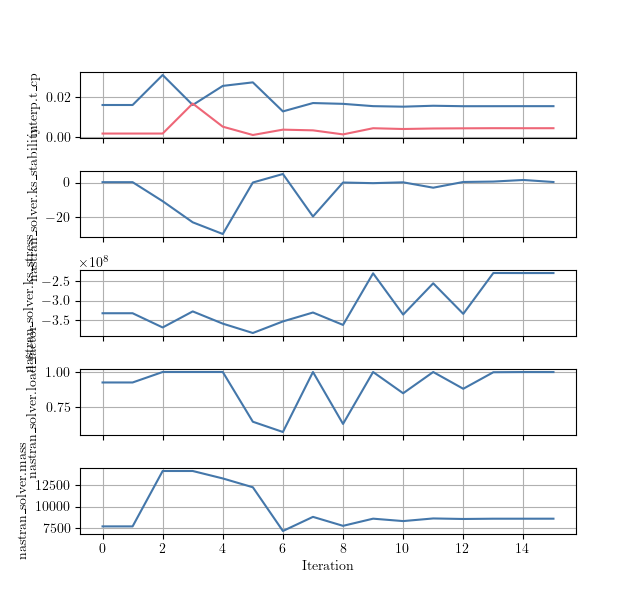

In [22]:
from resources import optimization_utils

# Plot optimization history
recorder_filename = "sol_106_hns_nonlinear_opt.sql"
recorder_filepath = os.path.join(DATA_DIRECTORY_PATH, recorder_filename)
fig, axes, hns_nonlinear_opt_histories = optimization_utils.plot_optimization_history(
    recorder_filepath
)

# Find index of last feasible design
hns_feasible_design_index = np.where(
    hns_nonlinear_opt_histories["nastran_solver.ks_stability"][:, 0]
    < OPTIMIZER_TOLERANCE
)[0][-1]

# Calculate and print mass reduction w.r.t. initial design
mass_reduction = 100 * (
    hns_nonlinear_opt_histories["nastran_solver.mass"][hns_feasible_design_index, 0]
    / hns_nonlinear_opt_histories["nastran_solver.mass"][0, 0]
    - 1
)
print(f"Mass change: {mass_reduction:.1f}%")

# Save plot
fig.savefig(
    os.path.join(FIGURES_DIRECTORY_PATH, "HnsNonlinearOptHistory.pdf"),
    bbox_inches="tight",
    pad_inches=0,
)

Plot history of nonlinear buckling optimization with LRA approach.

Requested variables at last iteration:
- interp.t_cp: [0.01668137 0.00159906]
- nastran_solver.ks_stability: [0.01482283]
- nastran_solver.ks_stress: [-2.96895168e+08]
- nastran_solver.load_factor: [0.99001604]
- nastran_solver.mass: [7854.34768751]
Mass change: 1.6%


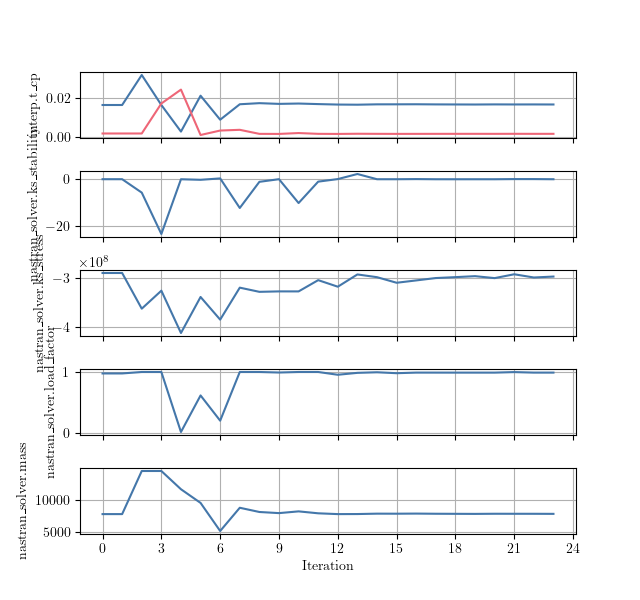

In [23]:
# Plot optimization history
recorder_filename = "sol_106_lra_nonlinear_opt.sql"
recorder_filepath = os.path.join(DATA_DIRECTORY_PATH, recorder_filename)
fig, axes, lra_nonlinear_opt_histories = optimization_utils.plot_optimization_history(
    recorder_filepath
)

# Find index of last feasible design
lra_feasible_design_index = np.where(
    lra_nonlinear_opt_histories["nastran_solver.ks_stability"][:, 0]
    < OPTIMIZER_TOLERANCE
)[0][-1]

# Calculate and print mass reduction w.r.t. initial design
mass_reduction = 100 * (
    lra_nonlinear_opt_histories["nastran_solver.mass"][lra_feasible_design_index, 0]
    / lra_nonlinear_opt_histories["nastran_solver.mass"][0, 0]
    - 1
)
print(f"Mass change: {mass_reduction:.1f}%")

# Save plot
fig.savefig(
    os.path.join(FIGURES_DIRECTORY_PATH, "LraNonlinearOptHistory.pdf"),
    bbox_inches="tight",
    pad_inches=0,
)

Plot bar chat of nonlinearly optimized thickness distributions.

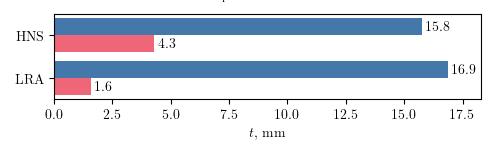

In [24]:
figure_name = "AeroLoadNonlinearOptThicknesses"
plot_thickness_bar_chart(
    hns_nonlinear_opt_histories,
    lra_nonlinear_opt_histories,
    figure_name,
    iter_indices=[hns_feasible_design_index, lra_feasible_design_index],
)

Plot bar chart of nonlinearly optimized masses.

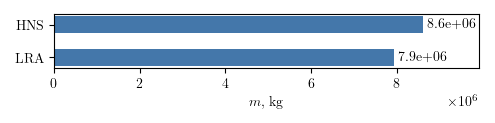

Mass difference between LRA and HNS models: -7.8%


In [25]:
figure_name = "AeroLoadNonlinearOptMasses"
plot_final_mass_bar_chart(
    hns_nonlinear_opt_histories,
    lra_nonlinear_opt_histories,
    figure_name,
    iter_indices=[hns_feasible_design_index, lra_feasible_design_index],
)

Plot twist of nonlinearly optimized structures.

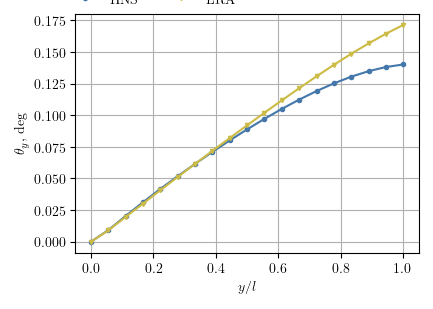

In [26]:
# Initialize dictionary of OP2 objects
sol_106_op2_dict = {}

# Create figure with one subplots
fig, ax = plt.subplots(figsize=(TEXTWIDTH_INCHES * 0.7, TEXTWIDTH_INCHES * 0.5))


# Iterate over aeroelastic coupling approaches
for i, approach in enumerate(coupling_approaches):
    
    # Read op2 file
    op2_filepath = os.path.join(
        DATA_DIRECTORY_PATH, f"sol_106_{approach}_nonlinear_opt_feasible" + ".op2"
    )
    sol_106_op2_dict[approach] = read_op2(op2_filename=op2_filepath, load_geometry=True, debug=None)

    # Read displacement data from OP2 object
    displacements = pynastran_utils.read_displacement_from_op2(
        op2=sol_106_op2_dict[approach],
        node_ids=np.hstack([front_nodes_ids, rear_nodes_ids]),
    )
    first_subcase_key = next(
        iter(sol_106_op2_dict[approach].displacements)
    )

    # Initialize array to store twist angles
    twist_angles = np.zeros_like(ribs_y_locations)

    # Iterate over ribs
    for j, rib_y in enumerate(ribs_y_locations):

        # Calculate twist angle from displacements of front and rear nodes
        twist_angles[j] = calculate_twist(
            front_nodes_xyz[j],
            displacements[front_nodes_ids[j]][first_subcase_key],
            rear_nodes_xyz[j],
            displacements[rear_nodes_ids[j]][first_subcase_key],
        )
        
    # Plot twist angles
    ax.plot(
        ribs_y_locations / L,
        np.degrees(twist_angles),
        label=approach.upper(),
        color=COLORS[i],
        marker=MARKERS[i],
    )

# Set labels and grid
ax.set_ylabel(r"$\theta_y$, deg")
ax.grid(True)
ax.set_xlabel("$y/l$")

# Add legend after tight layout
fig.tight_layout()
fig.legend(ncol=2, bbox_to_anchor=(0.57, 1.06), frameon=False)

# Show and save plot
plt.show()
fig.savefig(
    os.path.join(FIGURES_DIRECTORY_PATH, "NonlinearOptTwistComparison.pdf"),
    bbox_inches="tight",
    pad_inches=0,
)

Plot load-displacement diagrams.

Critical buckling load factor for HNS model: 0.99
Critical buckling load factor for LRA model: 0.74


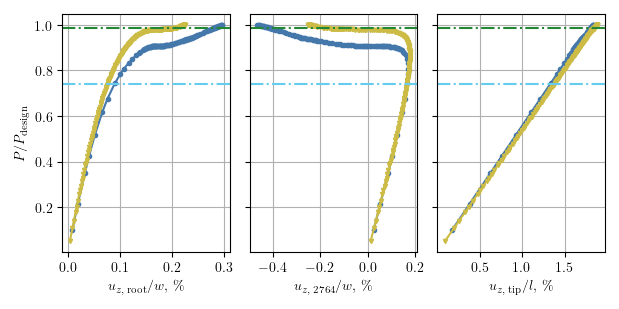

In [27]:
# Plot load-displacement diagrams
(
    fig,
    axes,
    nondimensional_displacements_dict,
    nondimensional_loads_dict,
    eigenvalues_dict,
    stable_lines,
) = plot_load_displacement_diagram(
    sol_106_op2_dict, input_name_dict, plot_node_ids, reference_lengths, max_nondimensional_load=1.0
)

# Define list of colors for linear buckling load lines
glass_ceiling_colors = [GLASS_CEILING_COLOR, COLORS[2]]

# Initialize list to store linear buckling load lines
linear_buckling_load_lines = [Line2D([0], [0])] * 2

# Iterate over the two linearly optimized structures
sol_105_op2_dict = {}
for i, key in enumerate(coupling_approaches):
    # Read linear buckling load
    op2_filepath = os.path.join(DATA_DIRECTORY_PATH, f"sol_105_{key}_nonlinear_opt.op2")
    sol_105_op2_dict[key] = read_op2(
        op2_filename=op2_filepath, load_geometry=True, debug=None
    )
    buckling_load_factor = (
        sol_105_op2_dict[key].eigenvectors[SECOND_SUBCASE_ID].eigrs[0]
    )
    print(
        f"Critical buckling load factor for {key.upper()} model: {buckling_load_factor:.2f}"
    )

    # Iterate over the two subplots
    for ax in axes:
        # Plot linear buckling load line
        linear_buckling_load_lines[i] = ax.axhline(
            y=buckling_load_factor,
            color=glass_ceiling_colors[i],
            linestyle="-.",
            label=f"{key.upper()} linear buckling load",
        )

# Set plot appearance for the first subplot
axes[0].set_xlabel("$u_{z,\,\mathrm{root}}/w$, \%")
axes[0].set_ylabel("$P/P_\mathrm{design}$")
axes[0].grid(visible=True)

# Set plot appearance for the second subplot
axes[1].set_xlabel(f"$u_{{z,\,\mathrm{{{max_disp_node_id:d}}}}}/w$, \%")
axes[1].grid(visible=True)

# Set plot appearance for the third subplot
axes[2].set_xlabel("$u_{z,\,\mathrm{tip}}/l$, \%")
axes[2].grid(visible=True)

# Add legend after tight layout
plt.tight_layout()
axes[0].legend(
    handles=stable_lines + linear_buckling_load_lines,
    loc="upper left",
    ncols=2,
    bbox_to_anchor=(-0.03, 1.25),
    frameon=False,
)

# Show and save plot
plt.show()
fig.savefig(
    os.path.join(
        FIGURES_DIRECTORY_PATH, "AeroLoadsNonlinearOptLoadDisplacementDiagram.pdf"
    ),
    bbox_inches="tight",
    pad_inches=0,
)

Compare critical buckling modes.

Critical buckling mode of structure optimized with HNS coupling:


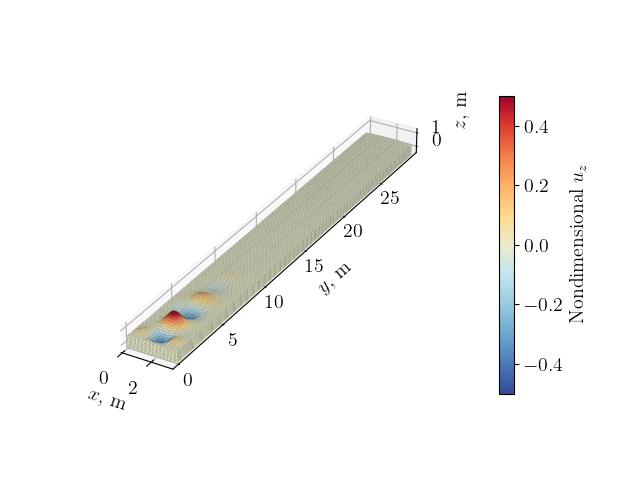

Critical buckling mode of structure optimized with LRA coupling:


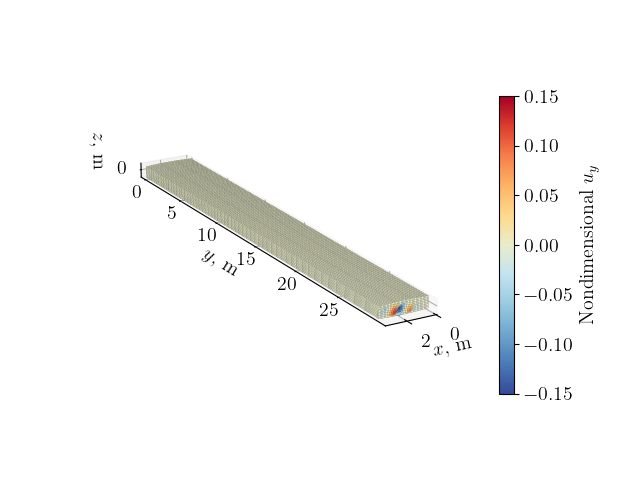

In [28]:
# Increase default font size for figures to be rendered side by side in the thesis
plt.rcParams.update({"font.size": DEFAULT_FONT_SIZE * (1 / 0.7)})

# Plot critical buckling mode of structure optimized with bending-only load
print(
    f"Critical buckling mode of structure optimized with {coupling_approaches[0].upper()} coupling:"
)
amplification_factor = 1.5  # amplification factor for displacements
clim = [-0.5, 0.5]
fig, ax, cbar = plot_utils.plot_eigenvector(
    op2=sol_105_op2_dict[coupling_approaches[0]],
    subcase_id=SECOND_SUBCASE_ID,
    displacement_component="tz",
    colormap="sunset",
    displacement_amplification_factor=amplification_factor,
    clim=clim,
)

# Adjust plot and show it
adjust_3d_plot(ax, cbar)
plt.show()

# Save figure
fig.savefig(
    os.path.join(
        FIGURES_DIRECTORY_PATH,
        f"NonlinearOptBucklingMode-{coupling_approaches[0].title()}.png",
    ),
    bbox_inches=BBOX_COLORBAR,
    pad_inches=0,
)

# Plot critical buckling mode of model with curved skin
print(
    f"Critical buckling mode of structure optimized with {coupling_approaches[1].upper()} coupling:"
)
clim = [-0.15, 0.15]
fig, ax, cbar = plot_utils.plot_eigenvector(
    op2=sol_105_op2_dict[coupling_approaches[1]],
    subcase_id=SECOND_SUBCASE_ID,
    displacement_component="ty",
    colormap="sunset",
    displacement_amplification_factor=amplification_factor,
    clim=clim,
)

# Adjust plot and show it
adjust_3d_plot(ax, cbar)
ax.view_init(20, 60)
ax.yaxis.labelpad = 100  # set y-axis label padding
ax.set_zticks([0])  # set z-ticks to zero only
plt.show()

# Save figure
fig.savefig(
    os.path.join(
        FIGURES_DIRECTORY_PATH,
        f"NonlinearOptBucklingMode-{coupling_approaches[1].title()}.png",
    ),
    bbox_inches=BBOX_COLORBAR,
    pad_inches=0,
)

# Reset default sizes
plt.rcParams.update({"font.size": DEFAULT_FONT_SIZE})

Compared deformations at design load.

Deformation of structure optimized with HNS coupling:


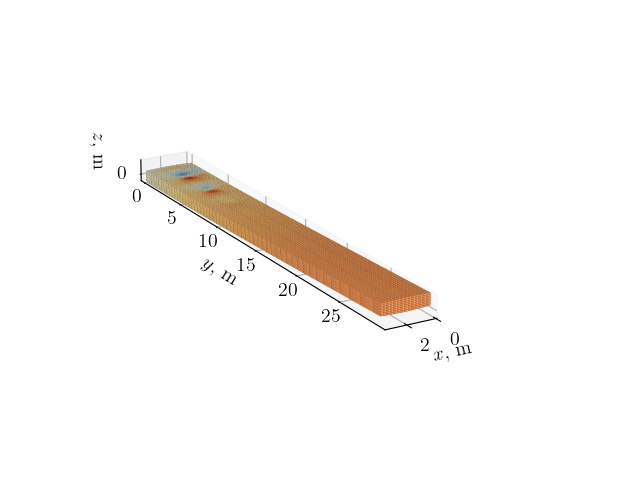

Deformation of structure optimized with LRA coupling:


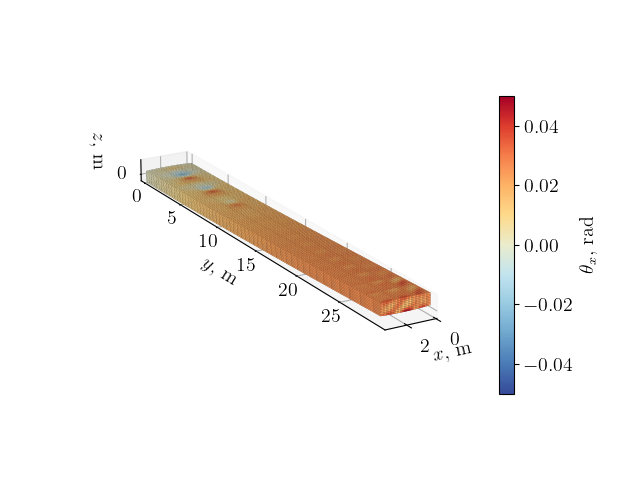

In [29]:
#
plt.rcParams.update({"font.size": DEFAULT_FONT_SIZE * (1 / 0.7)})

# Plot deformation of linearly optimized structure
print(
    f"Deformation of structure optimized with {coupling_approaches[0].upper()} coupling:"
)
clim = [-0.05, 0.05]  # color limits for deformation plot
fig, ax, cbar = plot_utils.plot_deformation(
    op2=sol_106_op2_dict[coupling_approaches[0]],
    subcase_id=first_subcase_key,
    displacement_component="rx",
    colormap="sunset",
    clim=clim,
)
adjust_3d_plot(ax, cbar)
ax.view_init(20, 60)
ax.yaxis.labelpad = 100  # set y-axis label padding
ax.set_zticks([0])  # set z-ticks to zero only
cbar.remove()
plt.show()
fig.savefig(
    os.path.join(
        FIGURES_DIRECTORY_PATH,
        f"NonlinearOpt{coupling_approaches[0].title()}Deformation.png",
    ),
    bbox_inches=BBOX_NO_COLORBAR,
    pad_inches=0,
)

# Plot deformation of nonlinearly optimized structure
print(
    f"Deformation of structure optimized with {coupling_approaches[1].upper()} coupling:"
)
fig, ax, cbar = plot_utils.plot_deformation(
    op2=sol_106_op2_dict[coupling_approaches[1]],
    subcase_id=first_subcase_key,
    displacement_component="rx",
    colormap="sunset",
    clim=clim,
)
adjust_3d_plot(ax, cbar)
ax.view_init(20, 60)
ax.yaxis.labelpad = 100  # set y-axis label padding
ax.set_zticks([0])  # set z-ticks to zero only
plt.show()
fig.savefig(
    os.path.join(
        FIGURES_DIRECTORY_PATH,
        f"NonlinearOpt{coupling_approaches[1].title()}Deformation.png",
    ),
    bbox_inches=BBOX_COLORBAR,
    pad_inches=0,
)

# Restore default font size
plt.rcParams.update({"font.size": DEFAULT_FONT_SIZE})